# B-Spline Trajectory Tokenizer - Experiments

This notebook explores using clamped B-splines to represent trajectories for robotics applications.

## Key Properties:
- **Clamped B-splines**: Start and end knots are repeated (degree+1 times) to ensure the curve passes through the first and last control points
- **Normalized space**: Time parameter t ∈ [0, 1], output range [-1, 1]
- **Configurable degree**: Default degree 4 (quintic-like smoothness)

## Regression Algorithm:
We use **least squares fitting** to find optimal control points. Given:
- Data points (t_i, y_i) for i = 1, ..., n
- B-spline basis functions B_j,k(t) for j = 0, ..., m-1

We solve: minimize ||A @ c - y||^2 where A[i,j] = B_j,k(t_i) and c are control point y-values.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Optional

# Set up nice plotting defaults
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 1. B-Spline Basis Functions

Implementation of the Cox-de Boor recursion formula for B-spline basis functions.

In [3]:
def create_clamped_knot_vector(n_control_points: int, degree: int) -> np.ndarray:
    """
    Create a clamped (open) knot vector for B-splines.
    
    For a clamped B-spline:
    - First (degree+1) knots are 0
    - Last (degree+1) knots are 1
    - Interior knots are uniformly spaced
    
    This ensures the curve passes through the first and last control points.
    
    Args:
        n_control_points: Number of control points
        degree: Degree of the B-spline (order = degree + 1)
        
    Returns:
        Knot vector of length (n_control_points + degree + 1)
    """
    n_knots = n_control_points + degree + 1
    n_interior = n_knots - 2 * (degree + 1)
    
    # Create knot vector
    knots = np.zeros(n_knots)
    
    # Clamped start: first (degree+1) knots = 0
    # Already zeros
    
    # Interior knots (uniformly spaced)
    if n_interior > 0:
        interior = np.linspace(0, 1, n_interior + 2)[1:-1]
        knots[degree + 1:degree + 1 + n_interior] = interior
    
    # Clamped end: last (degree+1) knots = 1
    knots[-(degree + 1):] = 1.0
    
    return knots


def bspline_basis(i: int, degree: int, t: float, knots: np.ndarray) -> float:
    """
    Compute B-spline basis function B_{i,degree}(t) using Cox-de Boor recursion.
    
    Args:
        i: Index of the basis function
        degree: Degree of the B-spline
        t: Parameter value
        knots: Knot vector
        
    Returns:
        Value of basis function B_{i,degree}(t)
    """
    # Base case: degree 0
    if degree == 0:
        # Handle the special case for t = 1 (last interval is closed on right)
        if t == knots[-1] and knots[i] <= t <= knots[i + 1]:
            return 1.0
        if knots[i] <= t < knots[i + 1]:
            return 1.0
        return 0.0
    
    # Recursive case
    left = 0.0
    right = 0.0
    
    # Left term
    denom_left = knots[i + degree] - knots[i]
    if denom_left != 0:
        left = (t - knots[i]) / denom_left * bspline_basis(i, degree - 1, t, knots)
    
    # Right term
    denom_right = knots[i + degree + 1] - knots[i + 1]
    if denom_right != 0:
        right = (knots[i + degree + 1] - t) / denom_right * bspline_basis(i + 1, degree - 1, t, knots)
    
    return left + right


def bspline_basis_matrix(t_values: np.ndarray, n_control_points: int, degree: int, 
                         knots: Optional[np.ndarray] = None) -> np.ndarray:
    """
    Compute the B-spline basis matrix for given parameter values.
    
    Args:
        t_values: Array of parameter values
        n_control_points: Number of control points
        degree: Degree of the B-spline
        knots: Optional knot vector (created if not provided)
        
    Returns:
        Matrix of shape (len(t_values), n_control_points) where
        M[i, j] = B_{j,degree}(t_values[i])
    """
    if knots is None:
        knots = create_clamped_knot_vector(n_control_points, degree)
    
    n_points = len(t_values)
    basis_matrix = np.zeros((n_points, n_control_points))
    
    for i, t in enumerate(t_values):
        for j in range(n_control_points):
            basis_matrix[i, j] = bspline_basis(j, degree, t, knots)
    
    return basis_matrix

## 2. B-Spline Evaluation and Regression

In [4]:
from scipy.optimize import lsq_linear


def evaluate_bspline(control_points: np.ndarray, t_values: np.ndarray, 
                     degree: int, knots: Optional[np.ndarray] = None) -> np.ndarray:
    """
    Evaluate a B-spline curve at given parameter values.
    
    Args:
        control_points: Control point values (1D array for scalar output)
        t_values: Parameter values to evaluate at
        degree: Degree of the B-spline
        knots: Optional knot vector
        
    Returns:
        Array of curve values at t_values
    """
    n_control_points = len(control_points)
    basis_matrix = bspline_basis_matrix(t_values, n_control_points, degree, knots)
    return basis_matrix @ control_points


def fit_bspline_least_squares(t_data: np.ndarray, y_data: np.ndarray, 
                               n_control_points: int, degree: int,
                               regularization: float = 0.0,
                               bounds: Optional[Tuple[float, float]] = None) -> Tuple[np.ndarray, np.ndarray, float]:
    """
    Fit a B-spline to data using least squares regression.
    
    This solves: minimize ||B @ c - y||^2 + lambda * ||c||^2
    where B is the basis matrix and c are the control points.
    
    For clamped B-splines, the first and last control points will
    naturally be close to the first and last data points.
    
    Args:
        t_data: Parameter values of data points
        y_data: Data point values
        n_control_points: Number of control points to use
        degree: Degree of the B-spline
        regularization: Ridge regularization parameter (default 0)
        bounds: Optional tuple (lower, upper) for control point bounds.
                If provided, uses constrained least squares to enforce
                lower <= control_points <= upper. E.g., (-2.0, 2.0)
        
    Returns:
        Tuple of (control_points, knot_vector, residual_norm)
    """
    # Create knot vector
    knots = create_clamped_knot_vector(n_control_points, degree)
    
    # Build basis matrix
    basis_matrix = bspline_basis_matrix(t_data, n_control_points, degree, knots)
    
    if bounds is not None:
        # Constrained least squares with box constraints
        # Solves: min ||Ax - b||^2 subject to lb <= x <= ub
        lower, upper = bounds
        
        if regularization > 0:
            # Add regularization by augmenting the system:
            # [B; sqrt(lambda)*I] @ c = [y; 0]
            sqrt_reg = np.sqrt(regularization)
            A_augmented = np.vstack([basis_matrix, sqrt_reg * np.eye(n_control_points)])
            b_augmented = np.concatenate([y_data, np.zeros(n_control_points)])
            result = lsq_linear(A_augmented, b_augmented, bounds=(lower, upper))
        else:
            result = lsq_linear(basis_matrix, y_data, bounds=(lower, upper))
        
        control_points = result.x
    elif regularization > 0:
        # Ridge regression: (B^T B + lambda*I) c = B^T y
        A = basis_matrix.T @ basis_matrix + regularization * np.eye(n_control_points)
        b = basis_matrix.T @ y_data
        control_points = np.linalg.solve(A, b)
    else:
        # Standard least squares using pseudoinverse
        control_points, residuals, rank, s = np.linalg.lstsq(basis_matrix, y_data, rcond=None)
    
    # Compute residual
    y_fitted = basis_matrix @ control_points
    residual_norm = np.linalg.norm(y_data - y_fitted)
    
    return control_points, knots, residual_norm

## 3. Visualization Utilities

In [5]:
def plot_bspline_fit(t_data: np.ndarray, y_data: np.ndarray, 
                     control_points: np.ndarray, knots: np.ndarray, 
                     degree: int, title: str = "B-Spline Fit",
                     show_basis: bool = False):
    """
    Visualize B-spline fit with data points and control polygon.
    """
    # Dense evaluation for smooth curve
    t_dense = np.linspace(0, 1, 200)
    y_fitted = evaluate_bspline(control_points, t_dense, degree, knots)
    
    # Control point x-positions (Greville abscissae for visualization)
    n_cp = len(control_points)
    cp_t = np.array([np.mean(knots[i+1:i+degree+1]) for i in range(n_cp)])
    
    if show_basis:
        fig, axes = plt.subplots(2, 1, figsize=(12, 10))
        ax1, ax2 = axes
    else:
        fig, ax1 = plt.subplots(1, 1, figsize=(12, 6))
    
    # Main plot
    ax1.plot(t_dense, y_fitted, 'b-', linewidth=2, label='B-spline curve')
    ax1.scatter(t_data, y_data, c='red', s=80, zorder=5, label='Data points')
    ax1.plot(cp_t, control_points, 'g--o', alpha=0.6, markersize=8, label='Control polygon')
    
    # Mark knots
    unique_knots = np.unique(knots)
    for k in unique_knots:
        ax1.axvline(k, color='gray', linestyle=':', alpha=0.3)
    
    ax1.set_xlabel('t (normalized time)')
    ax1.set_ylabel('y')
    ax1.set_title(title)
    ax1.legend()
    ax1.set_xlim(-0.05, 1.05)
    ax1.set_ylim(-1.3, 1.3)
    ax1.grid(True, alpha=0.3)
    
    # Basis functions plot
    if show_basis:
        basis_matrix = bspline_basis_matrix(t_dense, n_cp, degree, knots)
        for j in range(n_cp):
            ax2.plot(t_dense, basis_matrix[:, j], label=f'B_{j},{degree}')
        ax2.set_xlabel('t')
        ax2.set_ylabel('Basis value')
        ax2.set_title(f'B-spline Basis Functions (degree {degree})')
        ax2.legend(loc='upper right', fontsize=8)
        ax2.set_xlim(-0.05, 1.05)
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig

## 4. Experiment: Fitting a Sine-cubed Curve

Generate 10 points from a sine^3 curve and fit a B-spline.

In [6]:
# Parameters
DEGREE = 4  # B-spline degree
N_DATA_POINTS = 20  # Number of sample points
N_CONTROL_POINTS = 8  # Number of control points for fitting

# Generate sine^3 curve data
# t in [0, 1], y = sin(2*pi*t) which gives one full period in [-1, 1]
t_data = np.linspace(0, 1, N_DATA_POINTS)
y_data = np.sin(2 * np.pi * t_data) ** 3  # Full sine period, range [-1, 1]

print(f"Data points (t, y):")
for t, y in zip(t_data, y_data):
    print(f"  t={t:.3f}, y={y:.4f}")

Data points (t, y):
  t=0.000, y=0.0000
  t=0.053, y=0.0342
  t=0.105, y=0.2317
  t=0.158, y=0.5867
  t=0.211, y=0.9110
  t=0.263, y=0.9898
  t=0.316, y=0.7680
  t=0.368, y=0.3982
  t=0.421, y=0.1078
  t=0.474, y=0.0045
  t=0.526, y=-0.0045
  t=0.579, y=-0.1078
  t=0.632, y=-0.3982
  t=0.684, y=-0.7680
  t=0.737, y=-0.9898
  t=0.789, y=-0.9110
  t=0.842, y=-0.5867
  t=0.895, y=-0.2317
  t=0.947, y=-0.0342
  t=1.000, y=-0.0000


In [7]:
# Fit B-spline
control_points, knots, residual = fit_bspline_least_squares(
    t_data, y_data, N_CONTROL_POINTS, DEGREE
)

print(f"B-spline parameters:")
print(f"  Degree: {DEGREE}")
print(f"  Number of control points: {N_CONTROL_POINTS}")
print(f"  Knot vector: {knots}")
print(f"\nFitted control points:")
for i, cp in enumerate(control_points):
    print(f"  c[{i}] = {cp:.4f}")
print(f"\nResidual norm: {residual:.6f}")

B-spline parameters:
  Degree: 4
  Number of control points: 8
  Knot vector: [0.   0.   0.   0.   0.   0.25 0.5  0.75 1.   1.   1.   1.   1.  ]

Fitted control points:
  c[0] = 0.0373
  c[1] = -0.6107
  c[2] = 2.1251
  c[3] = -0.3747
  c[4] = 0.3747
  c[5] = -2.1251
  c[6] = 0.6107
  c[7] = -0.0373

Residual norm: 0.366077


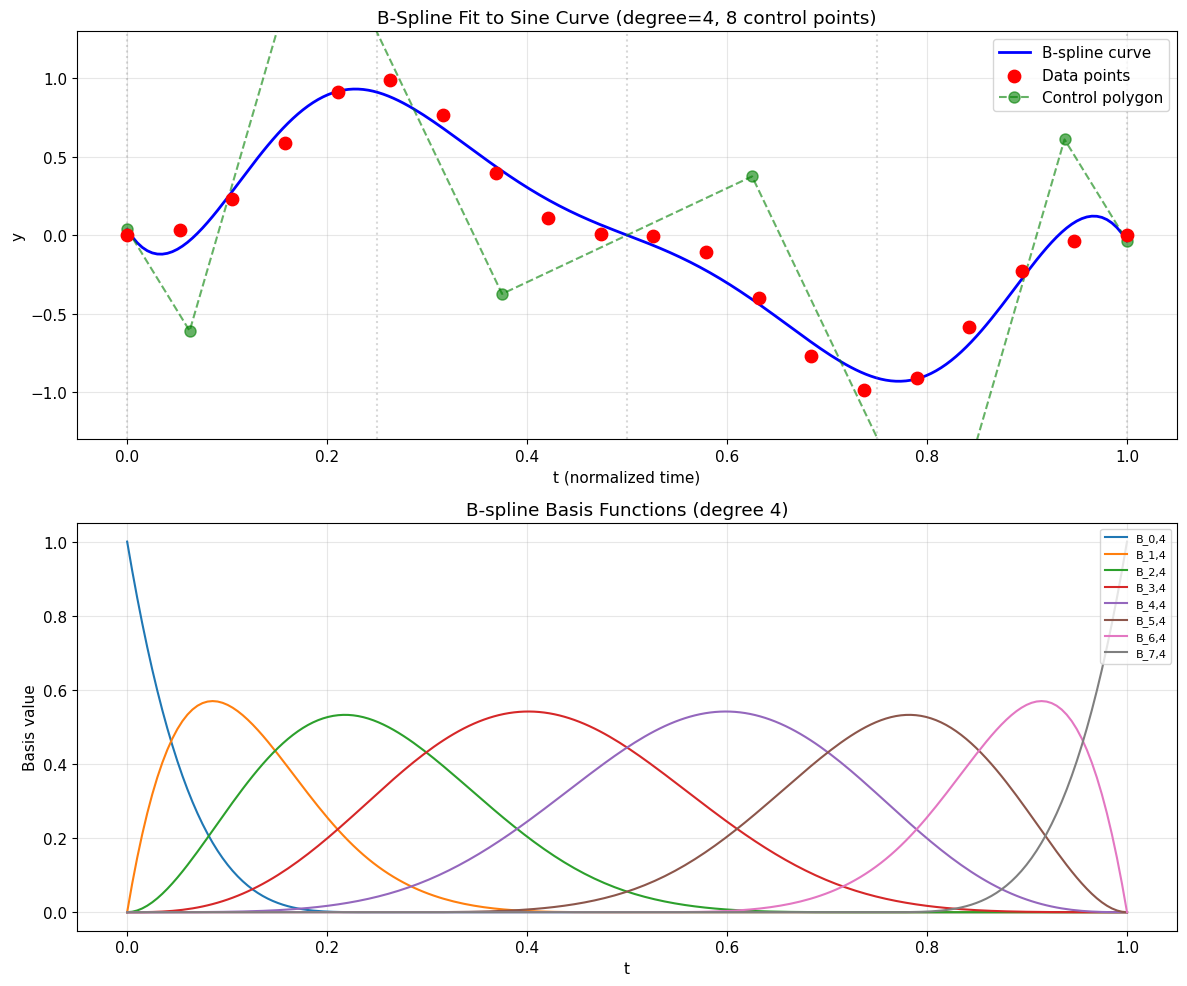

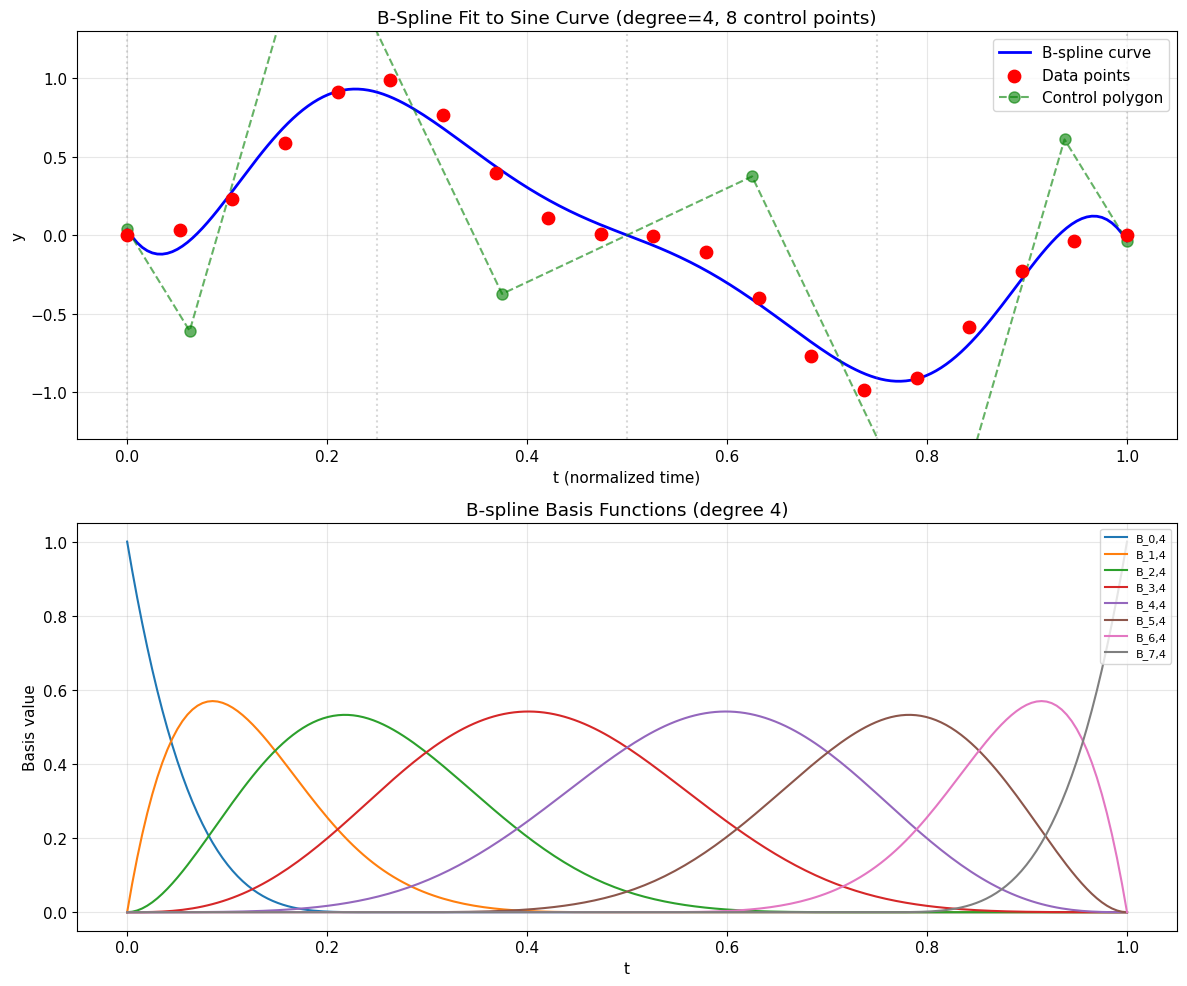

In [8]:
# Visualize the fit
plot_bspline_fit(
    t_data, y_data, control_points, knots, DEGREE,
    title=f"B-Spline Fit to Sine Curve (degree={DEGREE}, {N_CONTROL_POINTS} control points)",
    show_basis=True
)

## 5. Analysis: Effect of Number of Control Points

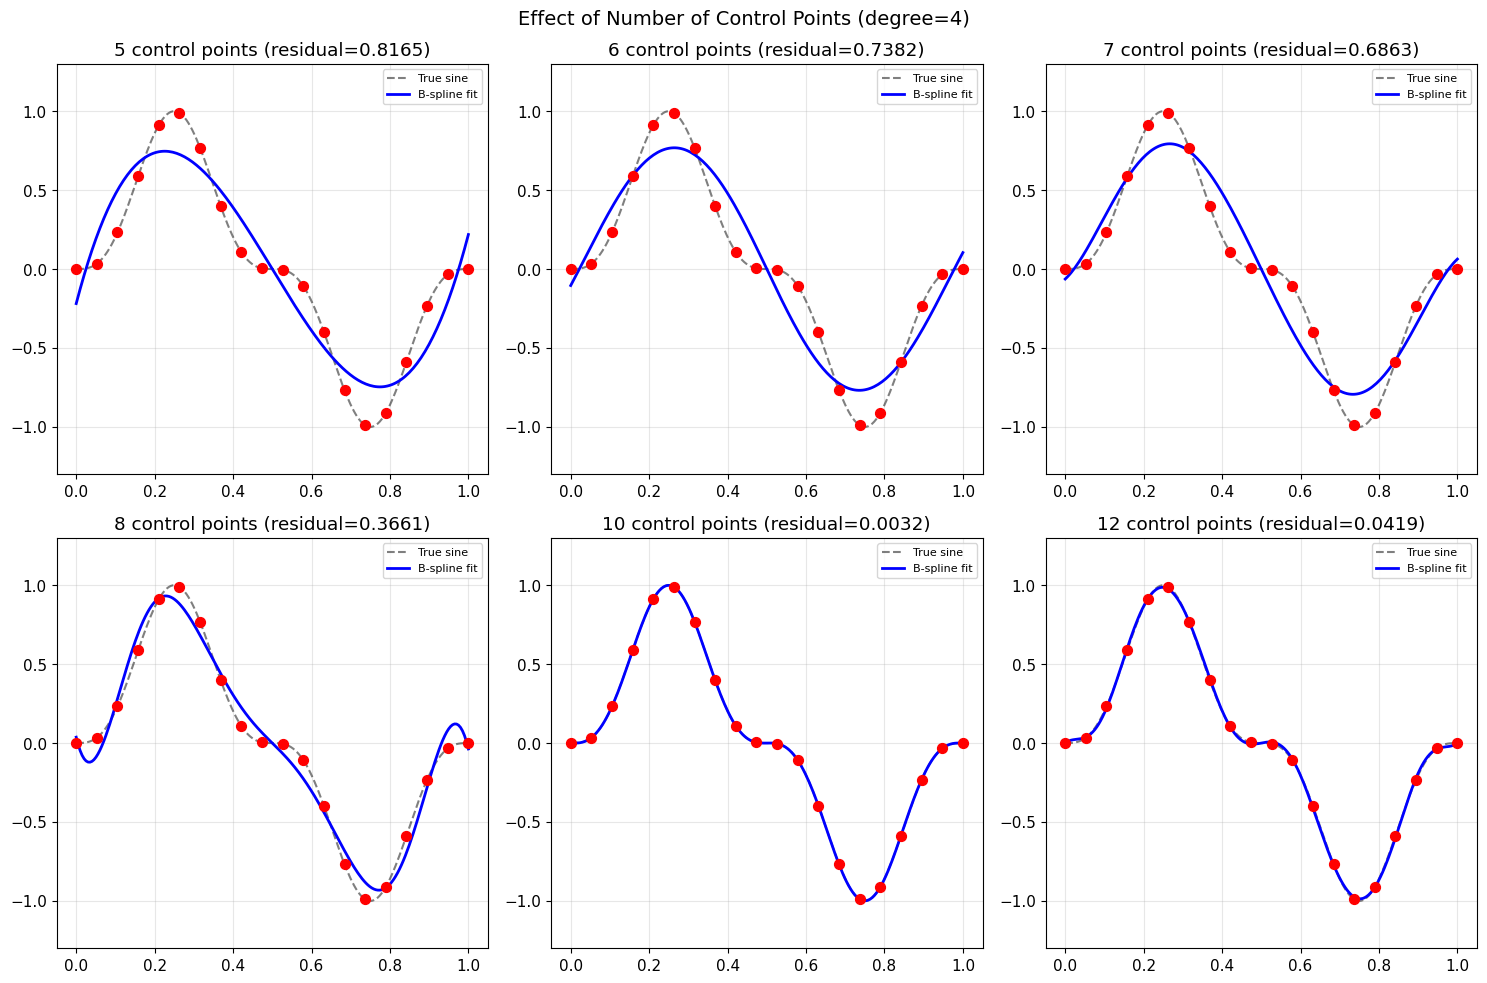

In [9]:
# Compare different numbers of control points
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

t_dense = np.linspace(0, 1, 200)
y_true = np.sin(2 * np.pi * t_dense) ** 3

for idx, n_cp in enumerate([5, 6, 7, 8, 10, 12]):
    if n_cp < DEGREE + 1:
        print(f"Skipping n_cp={n_cp}, need at least {DEGREE+1} control points for degree {DEGREE}")
        continue
    
    cp, kn, res = fit_bspline_least_squares(t_data, y_data, n_cp, DEGREE)
    y_fit = evaluate_bspline(cp, t_dense, DEGREE, kn)
    
    ax = axes[idx]
    ax.plot(t_dense, y_true, 'k--', alpha=0.5, label='True sine')
    ax.plot(t_dense, y_fit, 'b-', linewidth=2, label='B-spline fit')
    ax.scatter(t_data, y_data, c='red', s=50, zorder=5)
    ax.set_title(f'{n_cp} control points (residual={res:.4f})')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-1.3, 1.3)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle(f'Effect of Number of Control Points (degree={DEGREE})', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Analysis: Effect of Degree

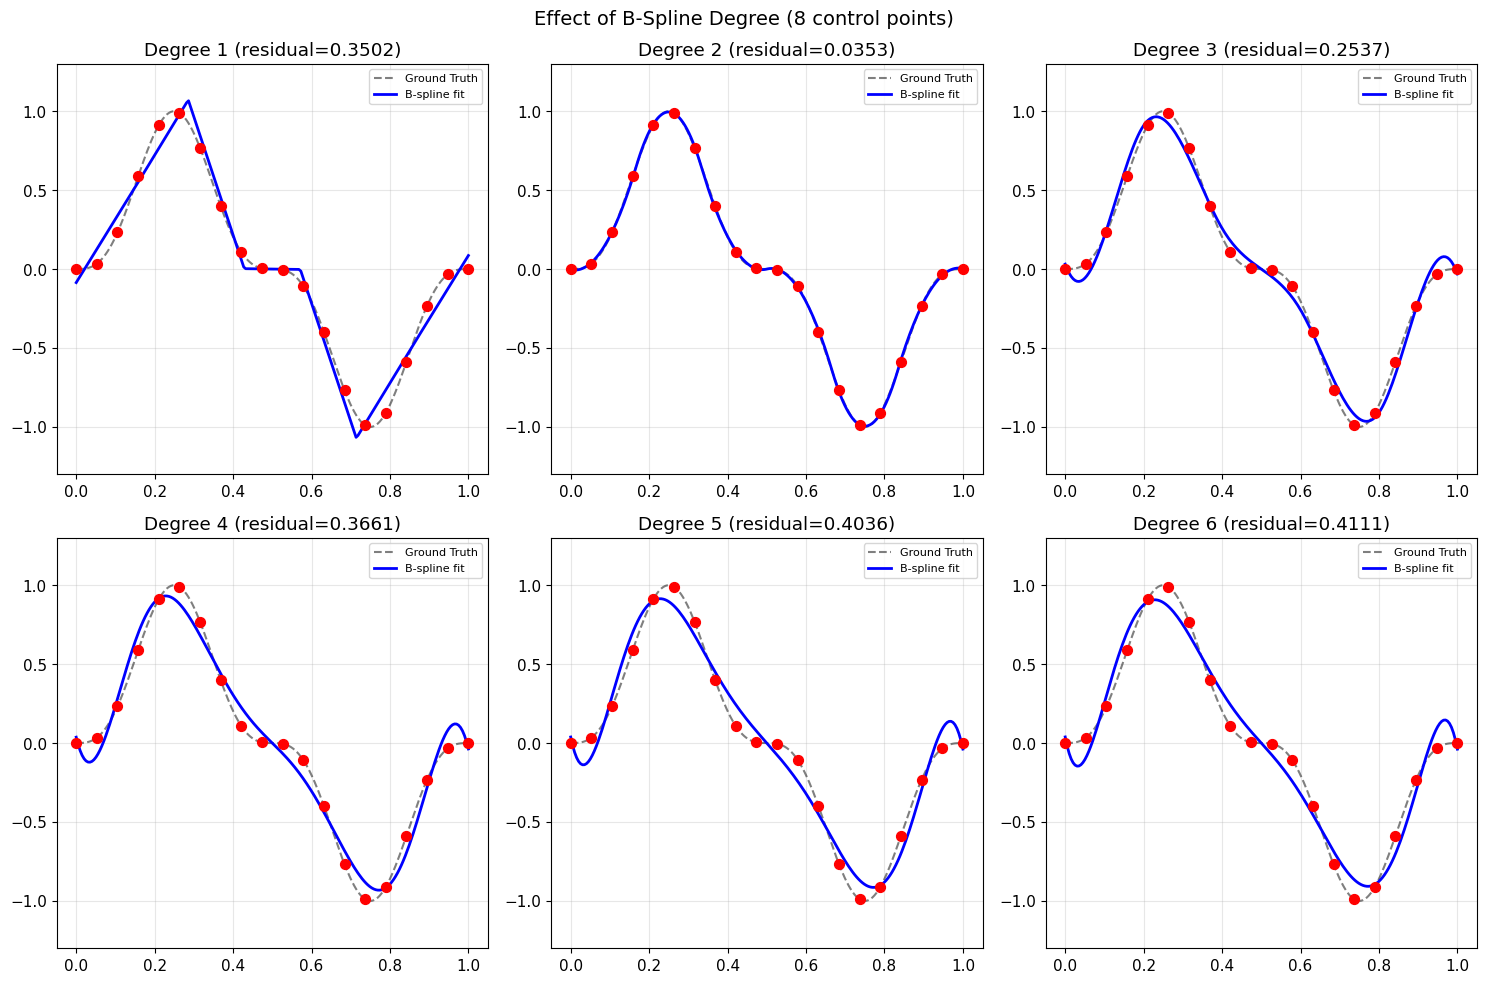

In [10]:
# Compare different degrees with fixed control points
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

n_cp_fixed = 8

for idx, deg in enumerate([1, 2, 3, 4, 5, 6]):
    if n_cp_fixed < deg + 1:
        print(f"Skipping degree={deg}, need more control points")
        continue
    
    cp, kn, res = fit_bspline_least_squares(t_data, y_data, n_cp_fixed, deg)
    y_fit = evaluate_bspline(cp, t_dense, deg, kn)
    
    ax = axes[idx]
    ax.plot(t_dense, y_true, 'k--', alpha=0.5, label='Ground Truth')
    ax.plot(t_dense, y_fit, 'b-', linewidth=2, label='B-spline fit')
    ax.scatter(t_data, y_data, c='red', s=50, zorder=5)
    ax.set_title(f'Degree {deg} (residual={res:.4f})')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-1.3, 1.3)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle(f'Effect of B-Spline Degree ({n_cp_fixed} control points)', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Verify Clamped Property

Check that the B-spline passes through (or very close to) the first and last data points.

In [11]:
# Evaluate at endpoints
y_at_0 = evaluate_bspline(control_points, np.array([0.0]), DEGREE, knots)[0]
y_at_1 = evaluate_bspline(control_points, np.array([1.0]), DEGREE, knots)[0]

print("Clamped B-spline endpoint verification:")
print(f"  At t=0: B-spline={y_at_0:.6f}, Data={y_data[0]:.6f}, Error={abs(y_at_0 - y_data[0]):.6f}")
print(f"  At t=1: B-spline={y_at_1:.6f}, Data={y_data[-1]:.6f}, Error={abs(y_at_1 - y_data[-1]):.6f}")
print(f"\n  First control point: {control_points[0]:.6f}")
print(f"  Last control point: {control_points[-1]:.6f}")
print("\nNote: For clamped B-splines, curve(0) = first control point, curve(1) = last control point")

Clamped B-spline endpoint verification:
  At t=0: B-spline=0.037324, Data=0.000000, Error=0.037324
  At t=1: B-spline=-0.037324, Data=-0.000000, Error=0.037324

  First control point: 0.037324
  Last control point: -0.037324

Note: For clamped B-splines, curve(0) = first control point, curve(1) = last control point


## 8. Reconstruction Error Analysis

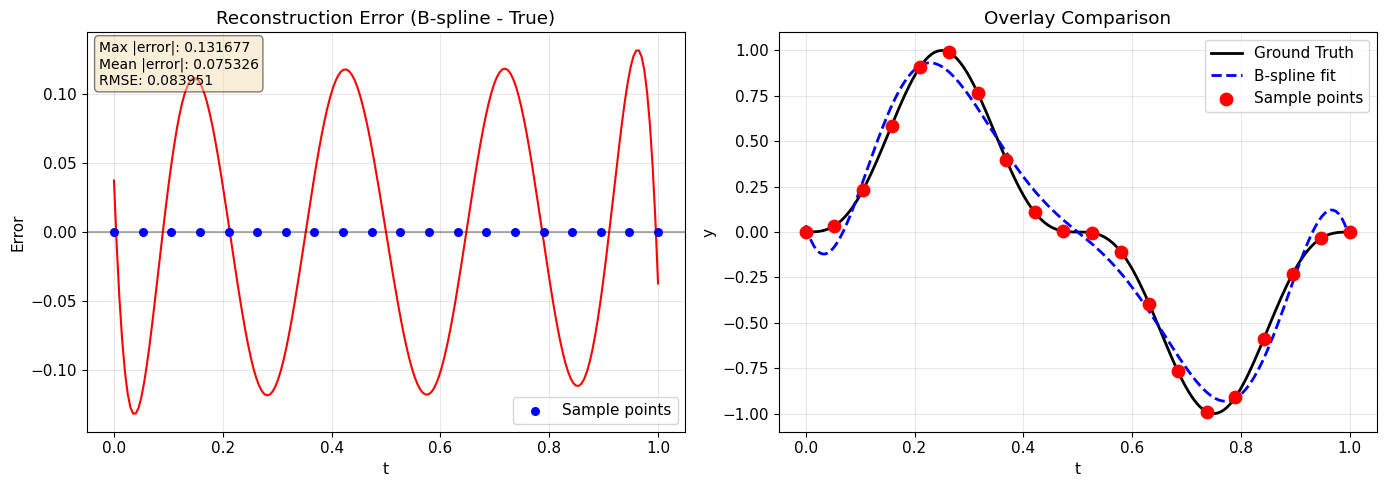


Error Statistics (degree=4, 8 control points):
  Maximum absolute error: 0.131677
  Mean absolute error: 0.075326
  Root mean square error: 0.083951


In [12]:
# Compute dense reconstruction error
y_fitted_dense = evaluate_bspline(control_points, t_dense, DEGREE, knots)
reconstruction_error = y_fitted_dense - y_true

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error plot
axes[0].plot(t_dense, reconstruction_error, 'r-', linewidth=1.5)
axes[0].axhline(0, color='k', linestyle='-', alpha=0.3)
axes[0].scatter(t_data, np.zeros_like(t_data), c='blue', s=30, zorder=5, label='Sample points')
axes[0].set_xlabel('t')
axes[0].set_ylabel('Error')
axes[0].set_title('Reconstruction Error (B-spline - True)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Error statistics
max_error = np.max(np.abs(reconstruction_error))
mean_error = np.mean(np.abs(reconstruction_error))
rmse = np.sqrt(np.mean(reconstruction_error**2))

stats_text = f"Max |error|: {max_error:.6f}\nMean |error|: {mean_error:.6f}\nRMSE: {rmse:.6f}"
axes[0].text(0.02, 0.98, stats_text, transform=axes[0].transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Comparison plot
axes[1].plot(t_dense, y_true, 'k-', linewidth=2, label='Ground Truth')
axes[1].plot(t_dense, y_fitted_dense, 'b--', linewidth=2, label='B-spline fit')
axes[1].scatter(t_data, y_data, c='red', s=80, zorder=5, label='Sample points')
axes[1].set_xlabel('t')
axes[1].set_ylabel('y')
axes[1].set_title('Overlay Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nError Statistics (degree={DEGREE}, {N_CONTROL_POINTS} control points):")
print(f"  Maximum absolute error: {max_error:.6f}")
print(f"  Mean absolute error: {mean_error:.6f}")
print(f"  Root mean square error: {rmse:.6f}")

## 9. Bounded Control Points for Tokenization

When fitting B-splines, control points can exceed the data range. For tokenization with a fixed quantization range (e.g., [-2, 2]), we need to constrain control points to valid bounds.

We use `scipy.optimize.lsq_linear` which solves:
$$\min_{\mathbf{c}} \|B\mathbf{c} - \mathbf{y}\|^2 \quad \text{subject to} \quad l \leq c_i \leq u$$

In [13]:
# Compare unbounded vs bounded fitting
BOUNDS = (-2.0, 2.0)  # Control point range for quantization

# Unbounded fit (original)
cp_unbounded, knots, res_unbounded = fit_bspline_least_squares(
    t_data, y_data, N_CONTROL_POINTS, DEGREE, bounds=None
)

# Bounded fit
cp_bounded, _, res_bounded = fit_bspline_least_squares(
    t_data, y_data, N_CONTROL_POINTS, DEGREE, bounds=BOUNDS
)

print("Control Point Comparison:")
print(f"{'Index':<6} {'Unbounded':<12} {'Bounded':<12} {'At Bound?':<10}")
print("-" * 40)
for i, (ub, bd) in enumerate(zip(cp_unbounded, cp_bounded)):
    at_bound = "YES" if abs(bd - BOUNDS[0]) < 1e-6 or abs(bd - BOUNDS[1]) < 1e-6 else ""
    print(f"{i:<6} {ub:<12.4f} {bd:<12.4f} {at_bound:<10}")

print(f"\nUnbounded: range=[{cp_unbounded.min():.4f}, {cp_unbounded.max():.4f}], residual={res_unbounded:.6f}")
print(f"Bounded:   range=[{cp_bounded.min():.4f}, {cp_bounded.max():.4f}], residual={res_bounded:.6f}")
print(f"Residual increase: {(res_bounded - res_unbounded) / res_unbounded * 100:.2f}%")

Control Point Comparison:
Index  Unbounded    Bounded      At Bound? 
----------------------------------------
0      0.0373       0.0294                 
1      -0.6107      -0.5423                
2      2.1251       2.0000       YES       
3      -0.3747      -0.2372                
4      0.3747       0.2372                 
5      -2.1251      -2.0000      YES       
6      0.6107       0.5423                 
7      -0.0373      -0.0294                

Unbounded: range=[-2.1251, 2.1251], residual=0.366077
Bounded:   range=[-2.0000, 2.0000], residual=0.371398
Residual increase: 1.45%


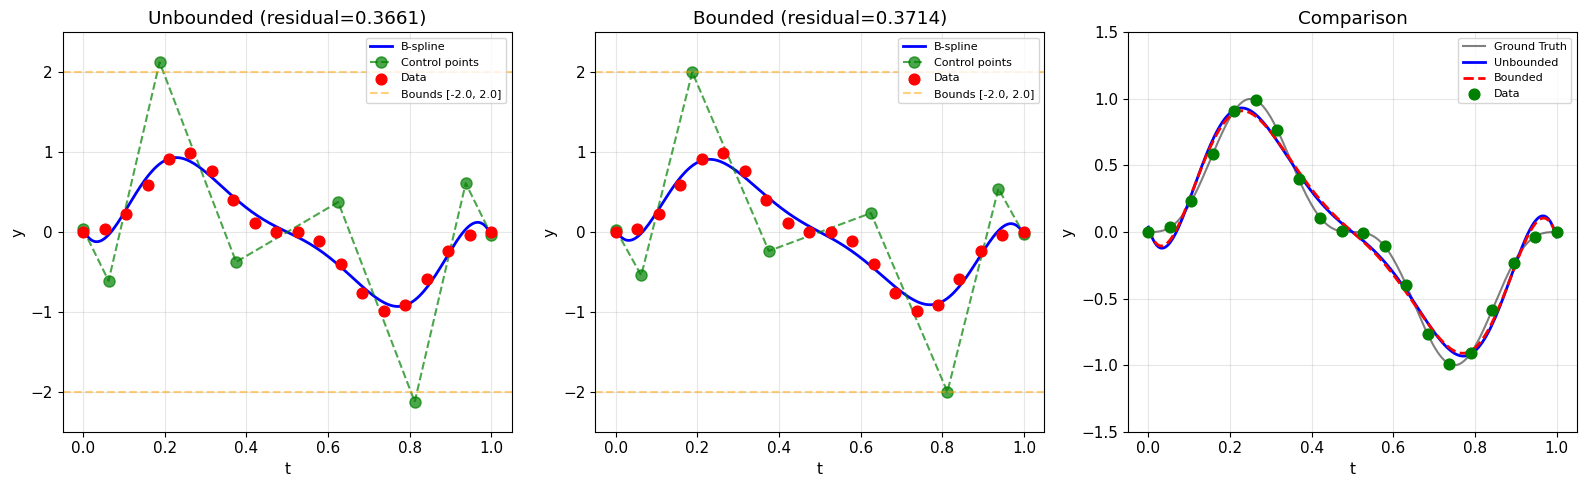


Max error vs ground truth:
  Unbounded: 0.131677
  Bounded:   0.133404


In [14]:
# Visualize bounded vs unbounded fit
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

t_dense = np.linspace(0, 1, 200)
y_unbounded = evaluate_bspline(cp_unbounded, t_dense, DEGREE, knots)
y_bounded = evaluate_bspline(cp_bounded, t_dense, DEGREE, knots)
y_true = np.sin(2 * np.pi * t_dense) ** 3

# Control point x-positions (Greville abscissae)
cp_t = np.array([np.mean(knots[i+1:i+DEGREE+1]) for i in range(N_CONTROL_POINTS)])

# Plot 1: Unbounded
ax = axes[0]
ax.plot(t_dense, y_unbounded, 'b-', linewidth=2, label='B-spline')
ax.plot(cp_t, cp_unbounded, 'g--o', alpha=0.7, markersize=8, label='Control points')
ax.scatter(t_data, y_data, c='red', s=60, zorder=5, label='Data')
ax.axhline(BOUNDS[0], color='orange', linestyle='--', alpha=0.5, label=f'Bounds [{BOUNDS[0]}, {BOUNDS[1]}]')
ax.axhline(BOUNDS[1], color='orange', linestyle='--', alpha=0.5)
ax.set_title(f'Unbounded (residual={res_unbounded:.4f})')
ax.set_xlabel('t')
ax.set_ylabel('y')
ax.set_ylim(-2.5, 2.5)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 2: Bounded
ax = axes[1]
ax.plot(t_dense, y_bounded, 'b-', linewidth=2, label='B-spline')
ax.plot(cp_t, cp_bounded, 'g--o', alpha=0.7, markersize=8, label='Control points')
ax.scatter(t_data, y_data, c='red', s=60, zorder=5, label='Data')
ax.axhline(BOUNDS[0], color='orange', linestyle='--', alpha=0.5, label=f'Bounds [{BOUNDS[0]}, {BOUNDS[1]}]')
ax.axhline(BOUNDS[1], color='orange', linestyle='--', alpha=0.5)
ax.set_title(f'Bounded (residual={res_bounded:.4f})')
ax.set_xlabel('t')
ax.set_ylabel('y')
ax.set_ylim(-2.5, 2.5)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 3: Comparison overlay
ax = axes[2]
ax.plot(t_dense, y_true, 'k-', linewidth=1.5, alpha=0.5, label='Ground Truth')
ax.plot(t_dense, y_unbounded, 'b-', linewidth=2, label='Unbounded')
ax.plot(t_dense, y_bounded, 'r--', linewidth=2, label='Bounded')
ax.scatter(t_data, y_data, c='green', s=60, zorder=5, label='Data')
ax.set_title('Comparison')
ax.set_xlabel('t')
ax.set_ylabel('y')
ax.set_ylim(-1.5, 1.5)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Error comparison
print(f"\nMax error vs ground truth:")
print(f"  Unbounded: {np.max(np.abs(y_unbounded - y_true)):.6f}")
print(f"  Bounded:   {np.max(np.abs(y_bounded - y_true)):.6f}")

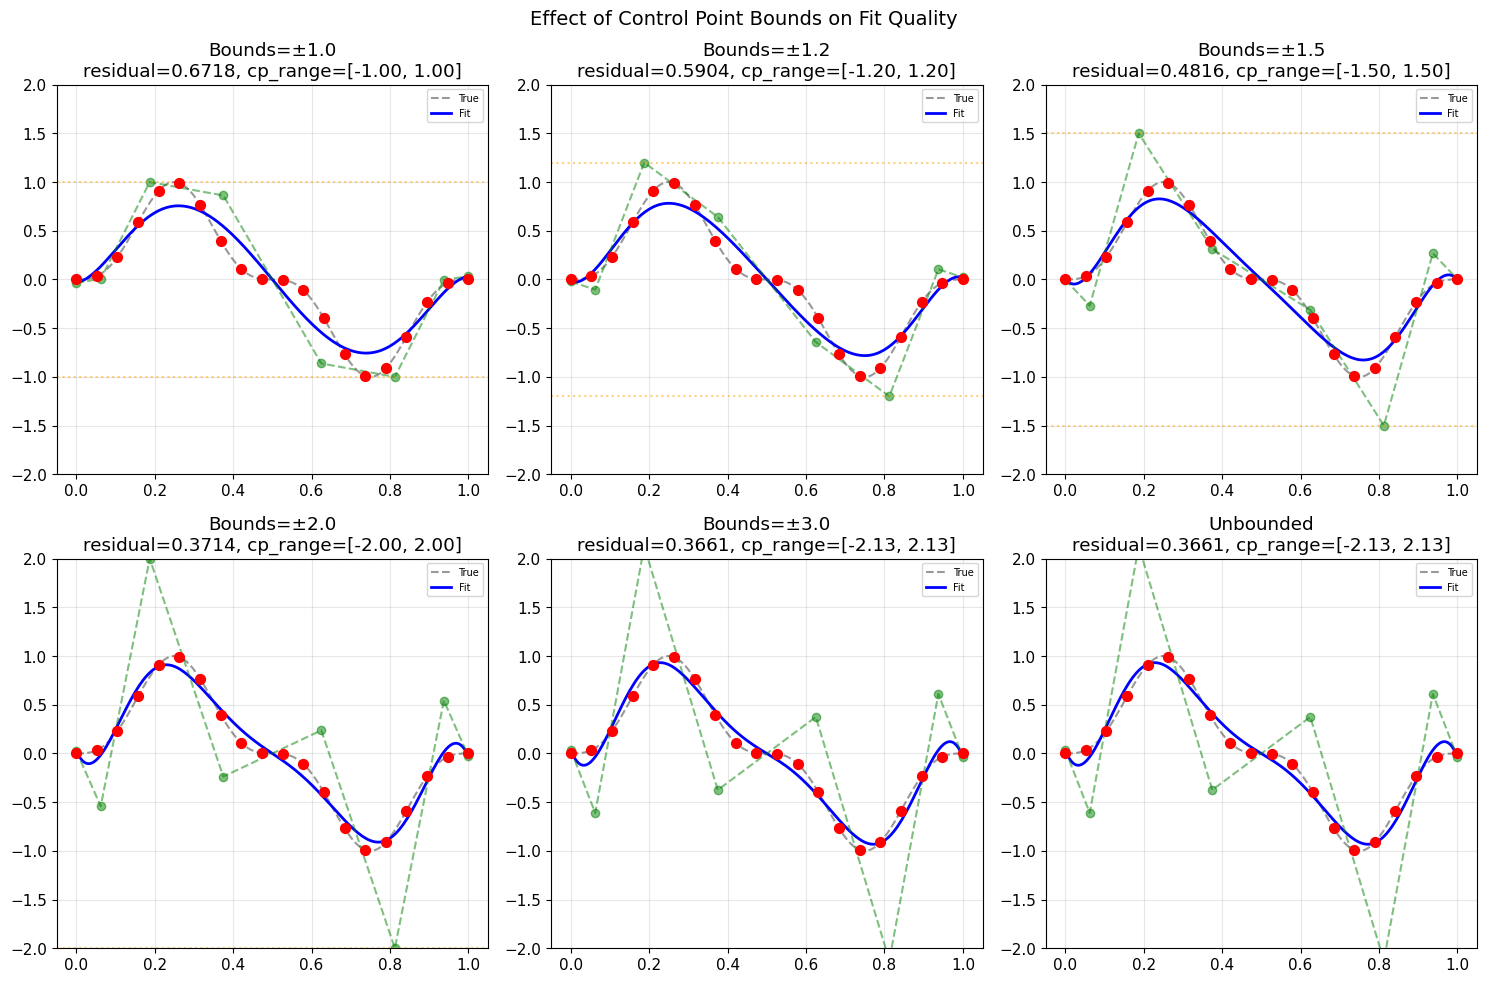

In [15]:
# Explore different bound ranges
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

bound_values = [1.0, 1.2, 1.5, 2.0, 3.0, None]  # None = unbounded

for idx, bnd in enumerate(bound_values):
    bounds = (-bnd, bnd) if bnd is not None else None
    cp, kn, res = fit_bspline_least_squares(t_data, y_data, N_CONTROL_POINTS, DEGREE, bounds=bounds)
    y_fit = evaluate_bspline(cp, t_dense, DEGREE, kn)
    
    ax = axes[idx]
    ax.plot(t_dense, y_true, 'k--', alpha=0.4, label='True')
    ax.plot(t_dense, y_fit, 'b-', linewidth=2, label='Fit')
    ax.scatter(t_data, y_data, c='red', s=50, zorder=5)
    
    # Show control points
    cp_t = np.array([np.mean(kn[i+1:i+DEGREE+1]) for i in range(N_CONTROL_POINTS)])
    ax.plot(cp_t, cp, 'g--o', alpha=0.5, markersize=6)
    
    if bnd is not None:
        ax.axhline(-bnd, color='orange', linestyle=':', alpha=0.5)
        ax.axhline(bnd, color='orange', linestyle=':', alpha=0.5)
    
    title = f'Bounds=±{bnd}' if bnd else 'Unbounded'
    ax.set_title(f'{title}\nresidual={res:.4f}, cp_range=[{cp.min():.2f}, {cp.max():.2f}]')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-2.0, 2.0)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Effect of Control Point Bounds on Fit Quality', fontsize=14)
plt.tight_layout()
plt.show()

### Control Point Distribution Analysis

Do B-spline control points follow a uniform distribution, or do they cluster around certain values? This affects whether uniform quantization is optimal or if we should use non-uniform bin sizes.

In [16]:
# Generate many different trajectory shapes and collect control points
np.random.seed(42)

all_control_points = []
trajectory_types = []

t_fit = np.linspace(0, 1, 20)  # 20 sample points

# 1. Sine waves with different frequencies and phases
for freq in [0.5, 1, 1.5, 2, 2.5, 3]:
    for phase in [0, np.pi/4, np.pi/2]:
        y = np.sin(2 * np.pi * freq * t_fit + phase)
        cp, _, _ = fit_bspline_least_squares(t_fit, y, 8, 4, bounds=(-2, 2))
        all_control_points.extend(cp)
        trajectory_types.extend(['sine'] * len(cp))

# 2. Polynomial trajectories (smooth motions)
for _ in range(20):
    # Random polynomial coefficients
    coeffs = np.random.randn(4) * 0.5
    y = np.polyval(coeffs, t_fit - 0.5)
    y = np.clip(y, -1, 1)  # Clip to valid range
    cp, _, _ = fit_bspline_least_squares(t_fit, y, 8, 4, bounds=(-2, 2))
    all_control_points.extend(cp)
    trajectory_types.extend(['poly'] * len(cp))

# 3. Step-like motions (common in robotics)
for _ in range(20):
    n_steps = np.random.randint(1, 4)
    y = np.zeros_like(t_fit)
    for _ in range(n_steps):
        step_pos = np.random.rand()
        step_height = np.random.rand() * 2 - 1
        y += step_height * (t_fit > step_pos)
    y = np.clip(y, -1, 1)
    cp, _, _ = fit_bspline_least_squares(t_fit, y, 8, 4, bounds=(-2, 2))
    all_control_points.extend(cp)
    trajectory_types.extend(['step'] * len(cp))

# 4. Smooth random trajectories (interpolated noise)
for _ in range(30):
    key_points = np.random.rand(5) * 2 - 1  # 5 random values in [-1, 1]
    key_t = np.linspace(0, 1, 5)
    y = np.interp(t_fit, key_t, key_points)
    cp, _, _ = fit_bspline_least_squares(t_fit, y, 8, 4, bounds=(-2, 2))
    all_control_points.extend(cp)
    trajectory_types.extend(['random'] * len(cp))

# 5. Linear ramps
for slope in np.linspace(-2, 2, 10):
    y = slope * (t_fit - 0.5)
    y = np.clip(y, -1, 1)
    cp, _, _ = fit_bspline_least_squares(t_fit, y, 8, 4, bounds=(-2, 2))
    all_control_points.extend(cp)
    trajectory_types.extend(['linear'] * len(cp))

all_control_points = np.array(all_control_points)
print(f"Collected {len(all_control_points)} control points from various trajectories")

Collected 784 control points from various trajectories


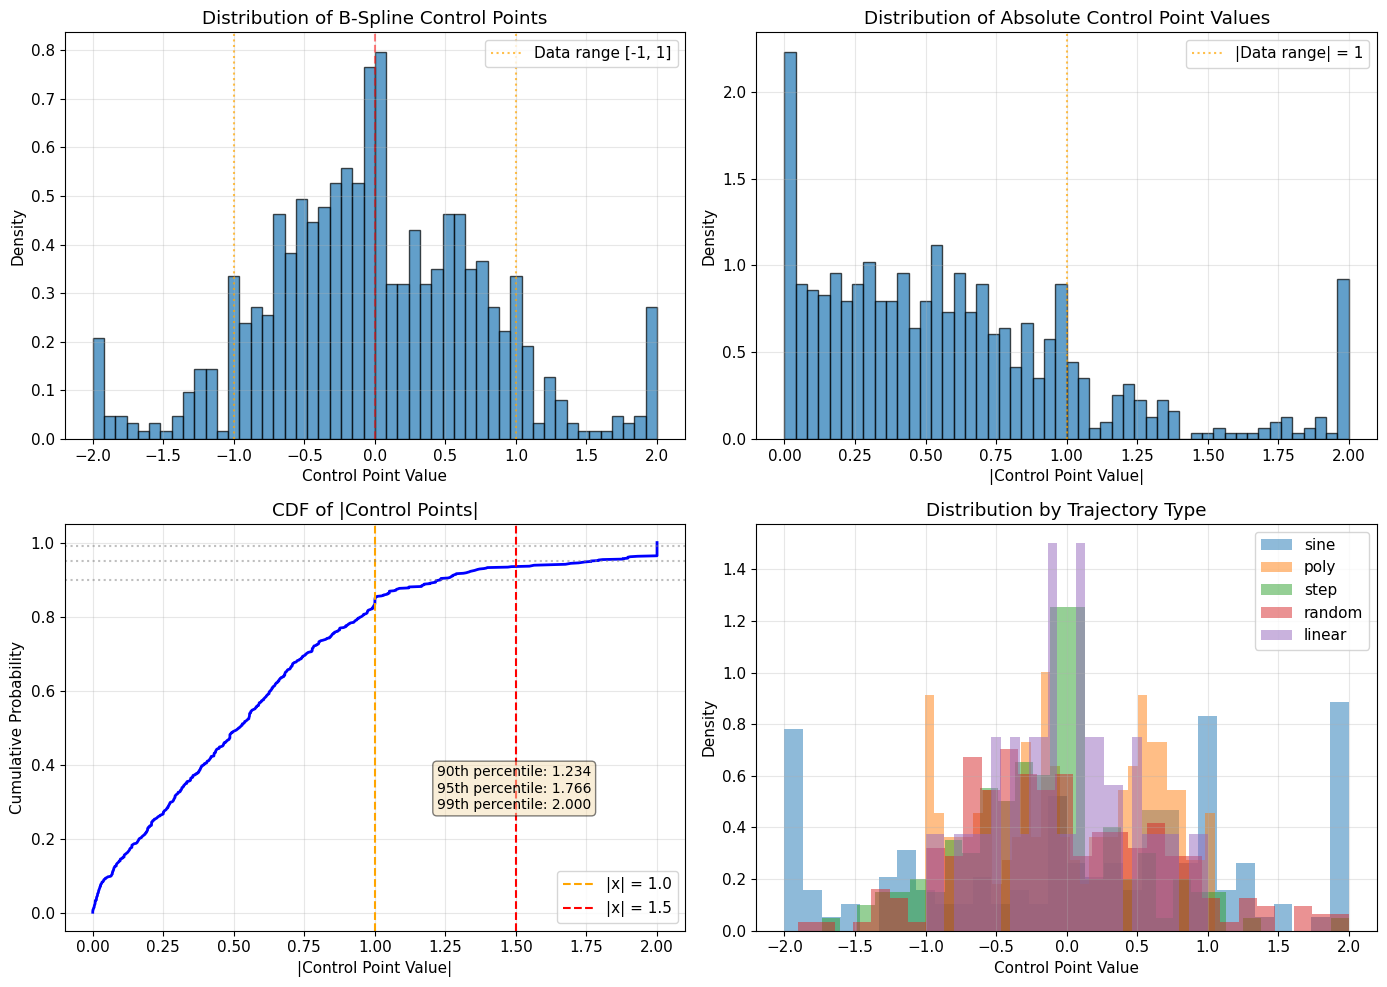

Control Point Statistics:
  Mean: -0.0066
  Std:  0.7745
  Min:  -2.0000
  Max:  2.0000

Percentiles of |control points|:
  90%: 1.2337
  95%: 1.7656
  99%: 2.0000

Fraction within data range [-1, 1]: 84.2%
Fraction within [-1.5, 1.5]: 93.5%


In [17]:
# Analyze the distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of all control points
ax = axes[0, 0]
counts, bins, _ = ax.hist(all_control_points, bins=50, density=True, alpha=0.7, edgecolor='black')
ax.axvline(0, color='red', linestyle='--', alpha=0.5)
ax.axvline(-1, color='orange', linestyle=':', alpha=0.7, label='Data range [-1, 1]')
ax.axvline(1, color='orange', linestyle=':', alpha=0.7)
ax.set_xlabel('Control Point Value')
ax.set_ylabel('Density')
ax.set_title('Distribution of B-Spline Control Points')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Histogram of absolute values (to see if large values are rare)
ax = axes[0, 1]
ax.hist(np.abs(all_control_points), bins=50, density=True, alpha=0.7, edgecolor='black')
ax.axvline(1, color='orange', linestyle=':', alpha=0.7, label='|Data range| = 1')
ax.set_xlabel('|Control Point Value|')
ax.set_ylabel('Density')
ax.set_title('Distribution of Absolute Control Point Values')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. CDF - what fraction of values fall within certain ranges
ax = axes[1, 0]
sorted_abs = np.sort(np.abs(all_control_points))
cdf = np.arange(1, len(sorted_abs) + 1) / len(sorted_abs)
ax.plot(sorted_abs, cdf, 'b-', linewidth=2)
ax.axvline(1.0, color='orange', linestyle='--', label='|x| = 1.0')
ax.axvline(1.5, color='red', linestyle='--', label='|x| = 1.5')
ax.axhline(0.9, color='gray', linestyle=':', alpha=0.5)
ax.axhline(0.95, color='gray', linestyle=':', alpha=0.5)
ax.axhline(0.99, color='gray', linestyle=':', alpha=0.5)

# Find percentiles
p90 = sorted_abs[int(0.90 * len(sorted_abs))]
p95 = sorted_abs[int(0.95 * len(sorted_abs))]
p99 = sorted_abs[int(0.99 * len(sorted_abs))]

ax.set_xlabel('|Control Point Value|')
ax.set_ylabel('Cumulative Probability')
ax.set_title('CDF of |Control Points|')
ax.legend()
ax.grid(True, alpha=0.3)
ax.text(0.6, 0.3, f'90th percentile: {p90:.3f}\n95th percentile: {p95:.3f}\n99th percentile: {p99:.3f}',
        transform=ax.transAxes, fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 4. Compare distributions by trajectory type
ax = axes[1, 1]
trajectory_types_arr = np.array(trajectory_types)
for ttype in ['sine', 'poly', 'step', 'random', 'linear']:
    mask = trajectory_types_arr == ttype
    ax.hist(all_control_points[mask], bins=30, density=True, alpha=0.5, label=ttype)
ax.set_xlabel('Control Point Value')
ax.set_ylabel('Density')
ax.set_title('Distribution by Trajectory Type')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
print("Control Point Statistics:")
print(f"  Mean: {np.mean(all_control_points):.4f}")
print(f"  Std:  {np.std(all_control_points):.4f}")
print(f"  Min:  {np.min(all_control_points):.4f}")
print(f"  Max:  {np.max(all_control_points):.4f}")
print(f"\nPercentiles of |control points|:")
print(f"  90%: {p90:.4f}")
print(f"  95%: {p95:.4f}")
print(f"  99%: {p99:.4f}")
print(f"\nFraction within data range [-1, 1]: {np.mean(np.abs(all_control_points) <= 1):.1%}")
print(f"Fraction within [-1.5, 1.5]: {np.mean(np.abs(all_control_points) <= 1.5):.1%}")

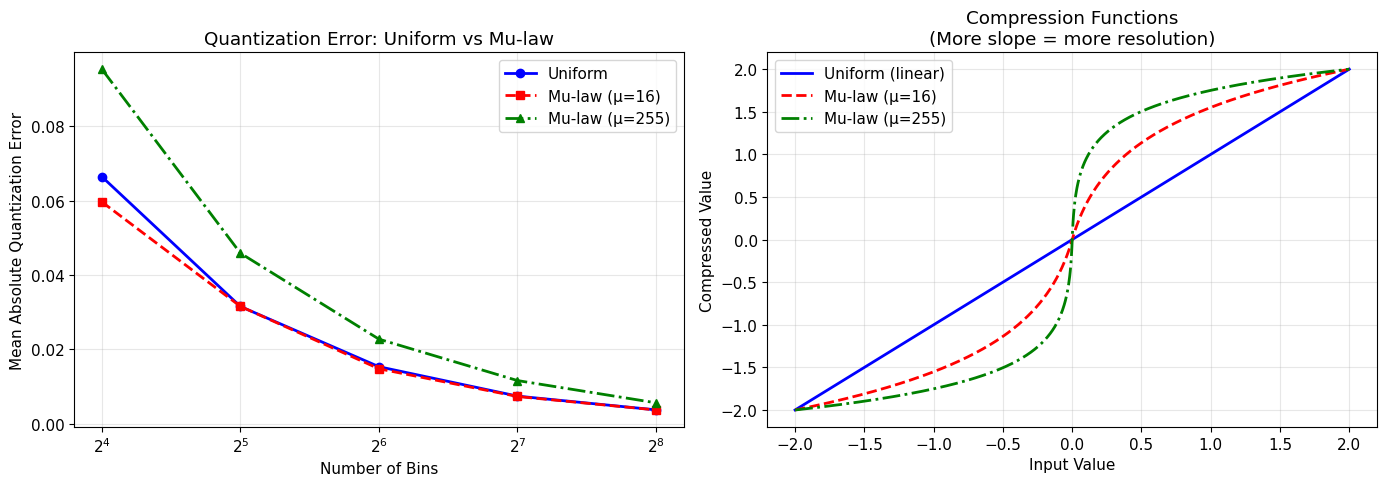


Mean Absolute Quantization Error:
Bins     Uniform      Mu-law(16)   Mu-law(255) 
--------------------------------------------
16       0.066450     0.059670     0.095358    
32       0.031550     0.031576     0.045883    
64       0.015353     0.014799     0.022765    
128      0.007446     0.007346     0.011629    
256      0.003746     0.003718     0.005643    


In [18]:
# Compare uniform vs non-uniform quantization
def uniform_quantize(values, n_bins, vmin, vmax):
    """Standard uniform quantization."""
    normalized = (values - vmin) / (vmax - vmin)
    quantized = np.round(normalized * (n_bins - 1)).astype(int)
    quantized = np.clip(quantized, 0, n_bins - 1)
    dequantized = quantized / (n_bins - 1) * (vmax - vmin) + vmin
    return quantized, dequantized

def nonuniform_quantize_mu_law(values, n_bins, vmin, vmax, mu=255):
    """
    Mu-law companding (used in audio): allocates more bins near zero.
    F(x) = sign(x) * ln(1 + mu*|x|) / ln(1 + mu)
    """
    # Normalize to [-1, 1]
    normalized = 2 * (values - vmin) / (vmax - vmin) - 1
    
    # Mu-law compression
    compressed = np.sign(normalized) * np.log1p(mu * np.abs(normalized)) / np.log1p(mu)
    
    # Quantize compressed values
    quantized = np.round((compressed + 1) / 2 * (n_bins - 1)).astype(int)
    quantized = np.clip(quantized, 0, n_bins - 1)
    
    # Dequantize
    compressed_recon = quantized / (n_bins - 1) * 2 - 1
    normalized_recon = np.sign(compressed_recon) * (np.exp(np.abs(compressed_recon) * np.log1p(mu)) - 1) / mu
    dequantized = (normalized_recon + 1) / 2 * (vmax - vmin) + vmin
    
    return quantized, dequantized

# Compare quantization error for different methods
n_bins_list = [16, 32, 64, 128, 256]
vmin, vmax = -2.0, 2.0

results = {'uniform': [], 'mu_law_16': [], 'mu_law_255': []}

for n_bins in n_bins_list:
    # Uniform
    _, deq_uniform = uniform_quantize(all_control_points, n_bins, vmin, vmax)
    results['uniform'].append(np.mean(np.abs(all_control_points - deq_uniform)))
    
    # Mu-law with different mu values
    _, deq_mu16 = nonuniform_quantize_mu_law(all_control_points, n_bins, vmin, vmax, mu=16)
    results['mu_law_16'].append(np.mean(np.abs(all_control_points - deq_mu16)))
    
    _, deq_mu255 = nonuniform_quantize_mu_law(all_control_points, n_bins, vmin, vmax, mu=255)
    results['mu_law_255'].append(np.mean(np.abs(all_control_points - deq_mu255)))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(n_bins_list, results['uniform'], 'b-o', label='Uniform', linewidth=2)
ax.plot(n_bins_list, results['mu_law_16'], 'r--s', label='Mu-law (μ=16)', linewidth=2)
ax.plot(n_bins_list, results['mu_law_255'], 'g-.^', label='Mu-law (μ=255)', linewidth=2)
ax.set_xlabel('Number of Bins')
ax.set_ylabel('Mean Absolute Quantization Error')
ax.set_title('Quantization Error: Uniform vs Mu-law')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log', base=2)

# Show the quantization functions
ax = axes[1]
x = np.linspace(-2, 2, 1000)
x_norm = x / 2  # Normalize to [-1, 1]

# Uniform (identity)
ax.plot(x, x, 'b-', label='Uniform (linear)', linewidth=2)

# Mu-law compression curves
for mu, color, style in [(16, 'r', '--'), (255, 'g', '-.')]:
    compressed = np.sign(x_norm) * np.log1p(mu * np.abs(x_norm)) / np.log1p(mu) * 2
    ax.plot(x, compressed, color=color, linestyle=style, label=f'Mu-law (μ={mu})', linewidth=2)

ax.set_xlabel('Input Value')
ax.set_ylabel('Compressed Value')
ax.set_title('Compression Functions\n(More slope = more resolution)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.2, 2.2)

plt.tight_layout()
plt.show()

print("\nMean Absolute Quantization Error:")
print(f"{'Bins':<8} {'Uniform':<12} {'Mu-law(16)':<12} {'Mu-law(255)':<12}")
print("-" * 44)
for i, n in enumerate(n_bins_list):
    print(f"{n:<8} {results['uniform'][i]:<12.6f} {results['mu_law_16'][i]:<12.6f} {results['mu_law_255'][i]:<12.6f}")

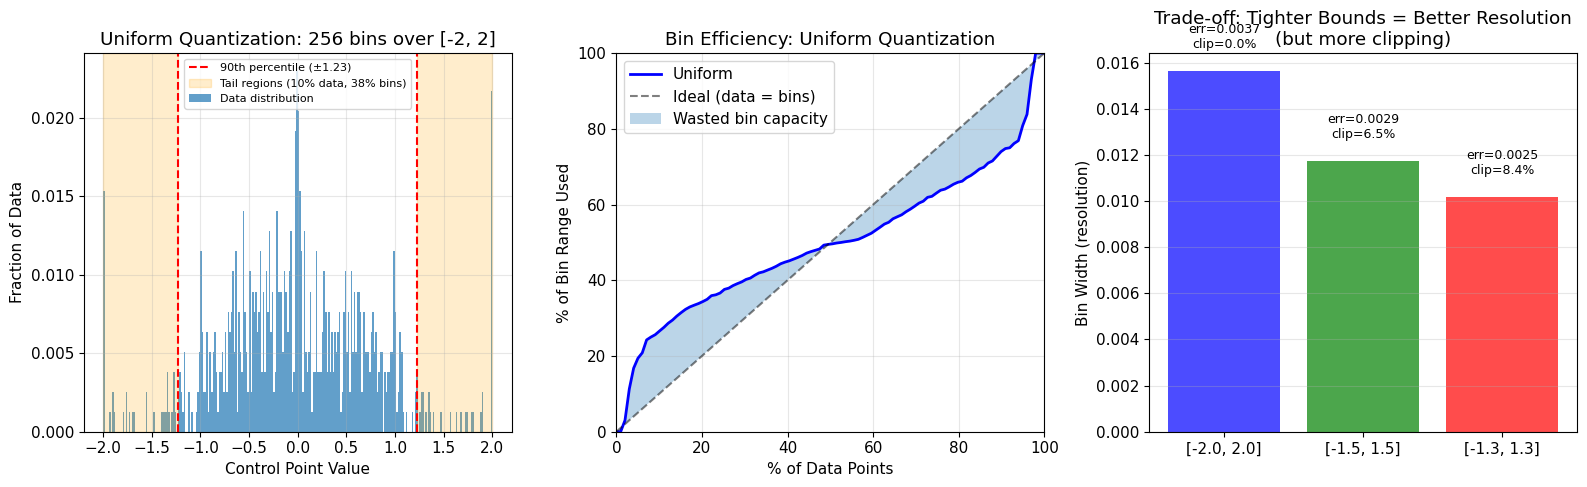

Quantization Efficiency Analysis:

With bounds [-2, 2] and 256 bins:
  Bin width: 0.0156
  90% of data in ±1.23 → uses 61.5% of bin range
  10% of data in tails → uses 38.5% of bin range

Alternative: bounds [-1.5, 1.5] with 256 bins:
  Bin width: 0.0117 (75% of original)
  Data clipped: 6.5%


In [19]:
# Visualize the bin allocation problem
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Show where bins go vs where data is
ax = axes[0]
n_bins = 256
bin_edges_uniform = np.linspace(-2, 2, n_bins + 1)
bin_centers = (bin_edges_uniform[:-1] + bin_edges_uniform[1:]) / 2

# Count data in each bin
hist_counts, _ = np.histogram(all_control_points, bins=bin_edges_uniform)
hist_counts_normalized = hist_counts / hist_counts.sum()

ax.bar(bin_centers, hist_counts_normalized, width=4/n_bins, alpha=0.7, label='Data distribution')
ax.axvline(-1.23, color='red', linestyle='--', label='90th percentile (±1.23)')
ax.axvline(1.23, color='red', linestyle='--')
ax.axvspan(-2, -1.23, alpha=0.2, color='orange', label='Tail regions (10% data, 38% bins)')
ax.axvspan(1.23, 2, alpha=0.2, color='orange')
ax.set_xlabel('Control Point Value')
ax.set_ylabel('Fraction of Data')
ax.set_title(f'Uniform Quantization: {n_bins} bins over [-2, 2]')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 2. Bin efficiency analysis
ax = axes[1]
# Calculate cumulative bins vs cumulative data
sorted_cp = np.sort(all_control_points)
n_total = len(sorted_cp)

# For uniform quantization: bin index is linear with value
bin_indices = ((sorted_cp + 2) / 4 * n_bins).astype(int)
bin_indices = np.clip(bin_indices, 0, n_bins - 1)

# Fraction of bins used vs fraction of data covered
data_fractions = np.linspace(0, 1, 100)
bins_used_uniform = []
for frac in data_fractions:
    idx = int(frac * n_total) if frac < 1 else n_total - 1
    if idx < n_total:
        val = sorted_cp[idx]
        bin_frac = (val + 2) / 4  # What fraction of bin range
        bins_used_uniform.append(bin_frac)
    else:
        bins_used_uniform.append(1.0)

ax.plot(data_fractions * 100, np.array(bins_used_uniform) * 100, 'b-', linewidth=2, label='Uniform')
ax.plot([0, 100], [0, 100], 'k--', alpha=0.5, label='Ideal (data = bins)')
ax.fill_between(data_fractions * 100, data_fractions * 100, np.array(bins_used_uniform) * 100, 
                alpha=0.3, label='Wasted bin capacity')
ax.set_xlabel('% of Data Points')
ax.set_ylabel('% of Bin Range Used')
ax.set_title('Bin Efficiency: Uniform Quantization')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

# 3. The solution: tighter bounds
ax = axes[2]
bounds_options = [(-2.0, 2.0), (-1.5, 1.5), (-1.3, 1.3)]
colors = ['blue', 'green', 'red']

for (vmin, vmax), color in zip(bounds_options, colors):
    # Calculate effective resolution (bin width)
    bin_width = (vmax - vmin) / n_bins
    
    # How much data is clipped?
    clipped = np.mean((all_control_points < vmin) | (all_control_points > vmax))
    
    # Mean quantization error for non-clipped data
    mask = (all_control_points >= vmin) & (all_control_points <= vmax)
    _, deq = uniform_quantize(all_control_points[mask], n_bins, vmin, vmax)
    mean_err = np.mean(np.abs(all_control_points[mask] - deq))
    
    ax.bar(f'[{vmin}, {vmax}]', bin_width, color=color, alpha=0.7)
    ax.text(bounds_options.index((vmin, vmax)), bin_width + 0.001, 
            f'err={mean_err:.4f}\nclip={clipped:.1%}', ha='center', fontsize=9)

ax.set_ylabel('Bin Width (resolution)')
ax.set_title(f'Trade-off: Tighter Bounds = Better Resolution\n(but more clipping)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary statistics
print("Quantization Efficiency Analysis:")
print(f"\nWith bounds [-2, 2] and 256 bins:")
print(f"  Bin width: {4/256:.4f}")
print(f"  90% of data in ±1.23 → uses {2.46/4*100:.1f}% of bin range")
print(f"  10% of data in tails → uses {(4-2.46)/4*100:.1f}% of bin range")
print(f"\nAlternative: bounds [-1.5, 1.5] with 256 bins:")
print(f"  Bin width: {3/256:.4f} ({3/256 / (4/256) * 100:.0f}% of original)")
clipped_1p5 = np.mean(np.abs(all_control_points) > 1.5)
print(f"  Data clipped: {clipped_1p5:.1%}")

### Experiment: Unbounded Fitting with Mu-law Quantization

The previous experiments used **bounded** fitting (`bounds=(-2, 2)`). Let's now test **unbounded** fitting 
(where control points are free to take any value) and compare uniform vs mu-law quantization with a 
wide fixed range `[-6, +6]`.

This tests the hypothesis that unbounded control points cluster near zero, making mu-law beneficial.

Collected 784 UNBOUNDED control points
Control point range: [-6.2934, 6.2934]


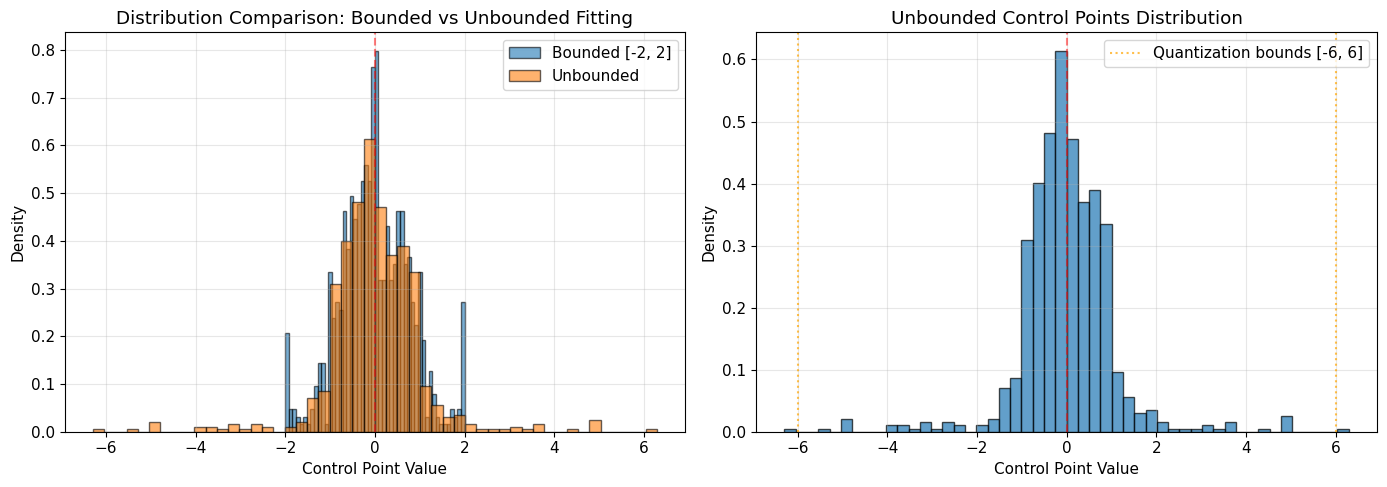

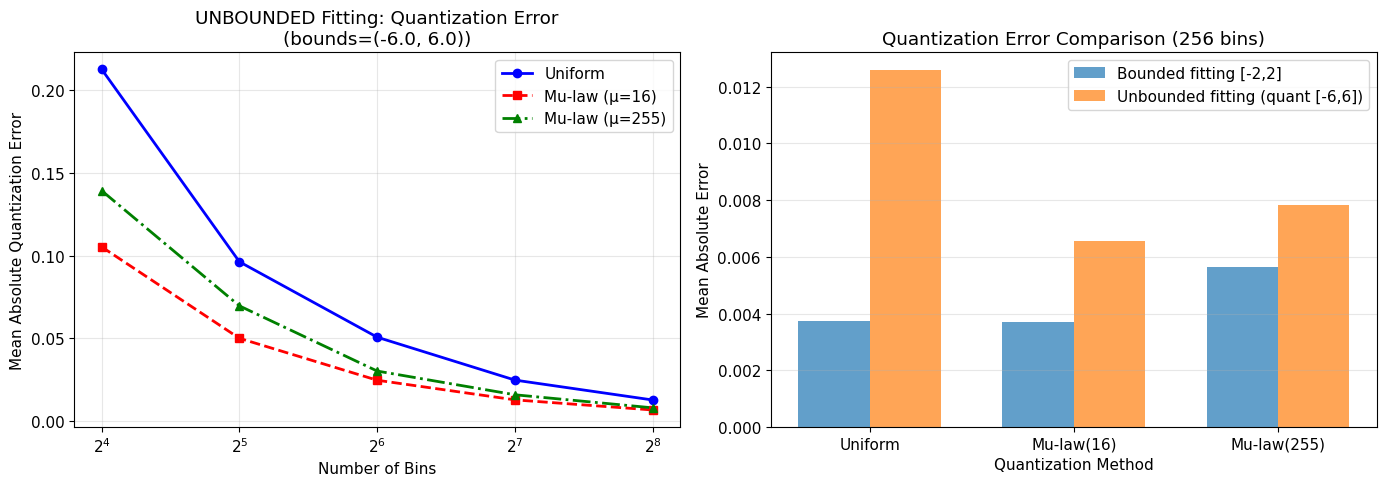


Mean Absolute Quantization Error (UNBOUNDED fitting, quantized to [-6, 6]):
Bins     Uniform      Mu-law(16)   Mu-law(255) 
--------------------------------------------
16       0.212868     0.105316     0.139364    
32       0.096271     0.049946     0.069575    
64       0.050613     0.024557     0.030113    
128      0.024634     0.012669     0.015750    
256      0.012586     0.006549     0.007840    

At 256 bins:
  Mu-law(16) vs Uniform: +48.0% (positive = mu-law better)
  Mu-law(255) vs Uniform: +37.7% (positive = mu-law better)

TRAJECTORY RECONSTRUCTION TEST

Test trajectory: 2.5 Hz sine wave
Unbounded control points: [-0.17052586  3.03032249 -2.52198905  0.79980621  0.79980621 -2.52198905
  3.03032249 -0.17052586]
Control point range: [-2.5220, 3.0303]
Fitting residual: 1.625348


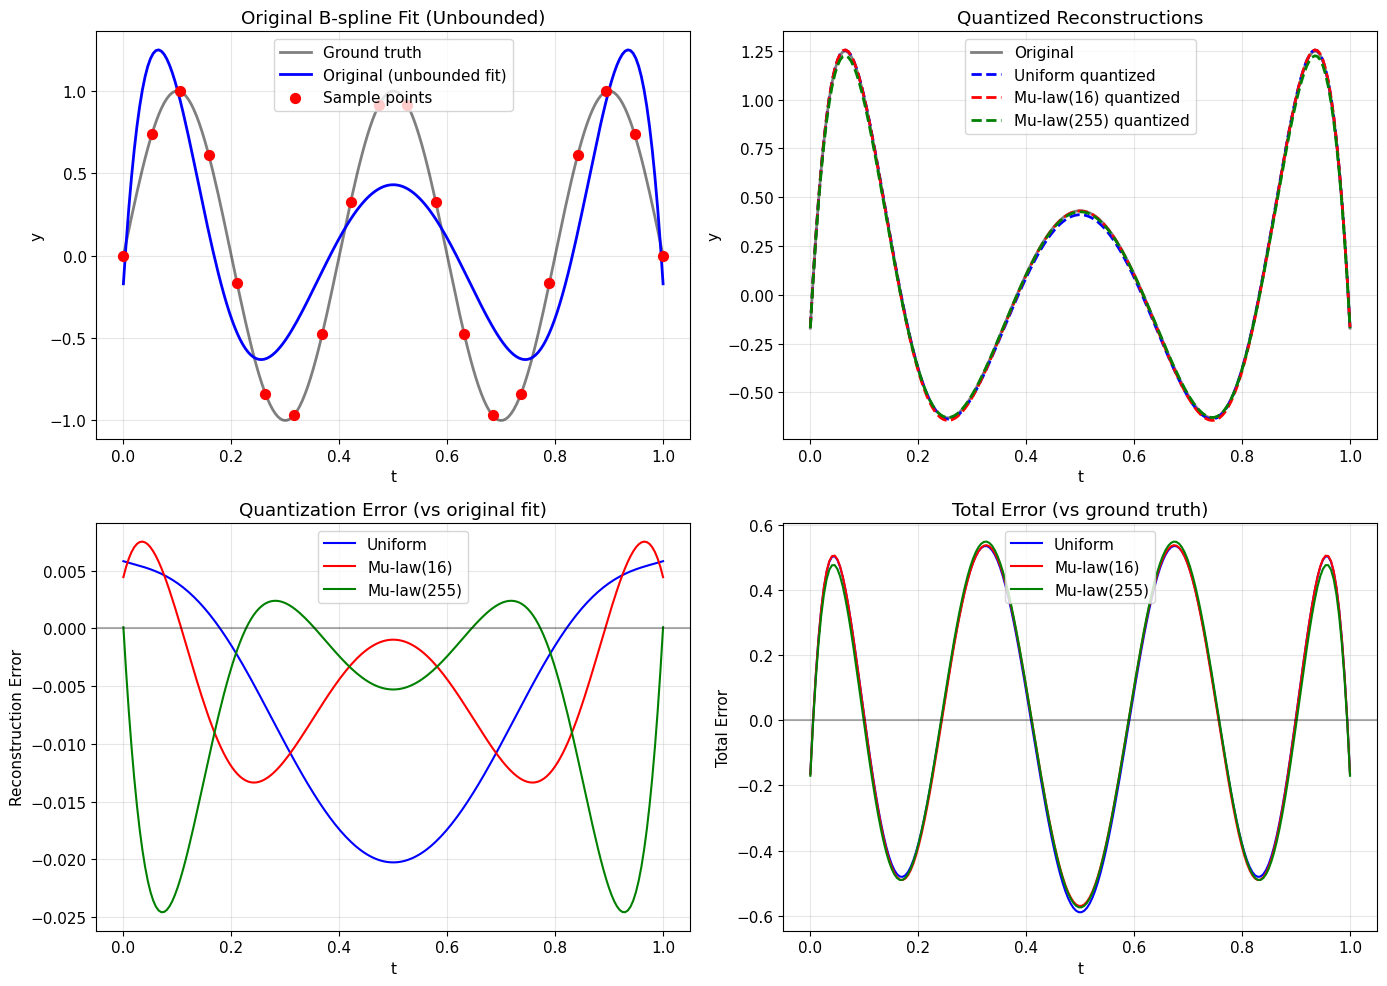


Reconstruction Error Statistics (256 bins, bounds=[-6,6]):
Method          Max Quant Err   Mean Quant Err  Max Total Err  
------------------------------------------------------------
Uniform         0.020258        0.009146        0.588986       
Mu-law(16)      0.013348        0.006929        0.569703       
Mu-law(255)     0.024573        0.007798        0.574012       


In [20]:
# Generate control points with UNBOUNDED fitting
np.random.seed(42)

unbounded_control_points = []
unbounded_trajectory_types = []

t_fit = np.linspace(0, 1, 20)  # 20 sample points

# 1. Sine waves with different frequencies and phases
for freq in [0.5, 1, 1.5, 2, 2.5, 3]:
    for phase in [0, np.pi/4, np.pi/2]:
        y = np.sin(2 * np.pi * freq * t_fit + phase)
        cp, _, _ = fit_bspline_least_squares(t_fit, y, 8, 4, bounds=None)  # UNBOUNDED
        unbounded_control_points.extend(cp)
        unbounded_trajectory_types.extend(['sine'] * len(cp))

# 2. Polynomial trajectories (smooth motions)
for _ in range(20):
    coeffs = np.random.randn(4) * 0.5
    y = np.polyval(coeffs, t_fit - 0.5)
    y = np.clip(y, -1, 1)
    cp, _, _ = fit_bspline_least_squares(t_fit, y, 8, 4, bounds=None)  # UNBOUNDED
    unbounded_control_points.extend(cp)
    unbounded_trajectory_types.extend(['poly'] * len(cp))

# 3. Step-like motions
for _ in range(20):
    n_steps = np.random.randint(1, 4)
    y = np.zeros_like(t_fit)
    for _ in range(n_steps):
        step_pos = np.random.rand()
        step_height = np.random.rand() * 2 - 1
        y += step_height * (t_fit > step_pos)
    y = np.clip(y, -1, 1)
    cp, _, _ = fit_bspline_least_squares(t_fit, y, 8, 4, bounds=None)  # UNBOUNDED
    unbounded_control_points.extend(cp)
    unbounded_trajectory_types.extend(['step'] * len(cp))

# 4. Smooth random trajectories
for _ in range(30):
    key_points = np.random.rand(5) * 2 - 1
    key_t = np.linspace(0, 1, 5)
    y = np.interp(t_fit, key_t, key_points)
    cp, _, _ = fit_bspline_least_squares(t_fit, y, 8, 4, bounds=None)  # UNBOUNDED
    unbounded_control_points.extend(cp)
    unbounded_trajectory_types.extend(['random'] * len(cp))

# 5. Linear ramps
for slope in np.linspace(-2, 2, 10):
    y = slope * (t_fit - 0.5)
    y = np.clip(y, -1, 1)
    cp, _, _ = fit_bspline_least_squares(t_fit, y, 8, 4, bounds=None)  # UNBOUNDED
    unbounded_control_points.extend(cp)
    unbounded_trajectory_types.extend(['linear'] * len(cp))

unbounded_control_points = np.array(unbounded_control_points)
print(f"Collected {len(unbounded_control_points)} UNBOUNDED control points")
print(f"Control point range: [{unbounded_control_points.min():.4f}, {unbounded_control_points.max():.4f}]")

# Compare distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(all_control_points, bins=50, density=True, alpha=0.6, label='Bounded [-2, 2]', edgecolor='black')
ax.hist(unbounded_control_points, bins=50, density=True, alpha=0.6, label='Unbounded', edgecolor='black')
ax.axvline(0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Control Point Value')
ax.set_ylabel('Density')
ax.set_title('Distribution Comparison: Bounded vs Unbounded Fitting')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(unbounded_control_points, bins=50, density=True, alpha=0.7, edgecolor='black')
ax.axvline(0, color='red', linestyle='--', alpha=0.5)
ax.axvline(-6, color='orange', linestyle=':', alpha=0.7, label='Quantization bounds [-6, 6]')
ax.axvline(6, color='orange', linestyle=':', alpha=0.7)
ax.set_xlabel('Control Point Value')
ax.set_ylabel('Density')
ax.set_title('Unbounded Control Points Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Now compare quantization: Uniform vs Mu-law with [-6, 6] bounds
QUANT_BOUNDS = (-6.0, 6.0)
n_bins_list = [16, 32, 64, 128, 256]

results_unbounded = {'uniform': [], 'mu_law_16': [], 'mu_law_255': []}

for n_bins in n_bins_list:
    # Uniform
    _, deq_uniform = uniform_quantize(unbounded_control_points, n_bins, QUANT_BOUNDS[0], QUANT_BOUNDS[1])
    results_unbounded['uniform'].append(np.mean(np.abs(unbounded_control_points - deq_uniform)))
    
    # Mu-law with different mu values
    _, deq_mu16 = nonuniform_quantize_mu_law(unbounded_control_points, n_bins, QUANT_BOUNDS[0], QUANT_BOUNDS[1], mu=16)
    results_unbounded['mu_law_16'].append(np.mean(np.abs(unbounded_control_points - deq_mu16)))
    
    _, deq_mu255 = nonuniform_quantize_mu_law(unbounded_control_points, n_bins, QUANT_BOUNDS[0], QUANT_BOUNDS[1], mu=255)
    results_unbounded['mu_law_255'].append(np.mean(np.abs(unbounded_control_points - deq_mu255)))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(n_bins_list, results_unbounded['uniform'], 'b-o', label='Uniform', linewidth=2)
ax.plot(n_bins_list, results_unbounded['mu_law_16'], 'r--s', label='Mu-law (μ=16)', linewidth=2)
ax.plot(n_bins_list, results_unbounded['mu_law_255'], 'g-.^', label='Mu-law (μ=255)', linewidth=2)
ax.set_xlabel('Number of Bins')
ax.set_ylabel('Mean Absolute Quantization Error')
ax.set_title(f'UNBOUNDED Fitting: Quantization Error\n(bounds={QUANT_BOUNDS})')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log', base=2)

# Compare bounded vs unbounded at 256 bins
ax = axes[1]
methods = ['Uniform', 'Mu-law(16)', 'Mu-law(255)']
bounded_errors = [results['uniform'][-1], results['mu_law_16'][-1], results['mu_law_255'][-1]]
unbounded_errors = [results_unbounded['uniform'][-1], results_unbounded['mu_law_16'][-1], results_unbounded['mu_law_255'][-1]]

x = np.arange(len(methods))
width = 0.35
ax.bar(x - width/2, bounded_errors, width, label='Bounded fitting [-2,2]', alpha=0.7)
ax.bar(x + width/2, unbounded_errors, width, label='Unbounded fitting (quant [-6,6])', alpha=0.7)
ax.set_xlabel('Quantization Method')
ax.set_ylabel('Mean Absolute Error')
ax.set_title('Quantization Error Comparison (256 bins)')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print results
print("\nMean Absolute Quantization Error (UNBOUNDED fitting, quantized to [-6, 6]):")
print(f"{'Bins':<8} {'Uniform':<12} {'Mu-law(16)':<12} {'Mu-law(255)':<12}")
print("-" * 44)
for i, n in enumerate(n_bins_list):
    print(f"{n:<8} {results_unbounded['uniform'][i]:<12.6f} {results_unbounded['mu_law_16'][i]:<12.6f} {results_unbounded['mu_law_255'][i]:<12.6f}")

# Calculate improvement
uniform_err = results_unbounded['uniform'][-1]
mu16_err = results_unbounded['mu_law_16'][-1]
mu255_err = results_unbounded['mu_law_255'][-1]
print(f"\nAt 256 bins:")
print(f"  Mu-law(16) vs Uniform: {(uniform_err - mu16_err) / uniform_err * 100:+.1f}% (positive = mu-law better)")
print(f"  Mu-law(255) vs Uniform: {(uniform_err - mu255_err) / uniform_err * 100:+.1f}% (positive = mu-law better)")

# Full trajectory reconstruction test
print("\n" + "="*60)
print("TRAJECTORY RECONSTRUCTION TEST")
print("="*60)

# Pick a challenging trajectory (sine wave with high frequency)
t_test = np.linspace(0, 1, 20)
y_test = np.sin(2 * np.pi * 2.5 * t_test)  # 2.5 Hz sine

# Fit unbounded
cp_unbounded_test, knots_test, res_unbounded_test = fit_bspline_least_squares(
    t_test, y_test, 8, 4, bounds=None
)

print(f"\nTest trajectory: 2.5 Hz sine wave")
print(f"Unbounded control points: {cp_unbounded_test}")
print(f"Control point range: [{cp_unbounded_test.min():.4f}, {cp_unbounded_test.max():.4f}]")
print(f"Fitting residual: {res_unbounded_test:.6f}")

# Quantize with uniform and mu-law
n_bins = 256
_, cp_deq_uniform = uniform_quantize(cp_unbounded_test, n_bins, -6, 6)
_, cp_deq_mu16 = nonuniform_quantize_mu_law(cp_unbounded_test, n_bins, -6, 6, mu=16)
_, cp_deq_mu255 = nonuniform_quantize_mu_law(cp_unbounded_test, n_bins, -6, 6, mu=255)

# Reconstruct trajectories
t_dense = np.linspace(0, 1, 200)
y_original = evaluate_bspline(cp_unbounded_test, t_dense, 4, knots_test)
y_uniform = evaluate_bspline(cp_deq_uniform, t_dense, 4, knots_test)
y_mu16 = evaluate_bspline(cp_deq_mu16, t_dense, 4, knots_test)
y_mu255 = evaluate_bspline(cp_deq_mu255, t_dense, 4, knots_test)
y_true = np.sin(2 * np.pi * 2.5 * t_dense)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Trajectory comparison
ax = axes[0, 0]
ax.plot(t_dense, y_true, 'k-', linewidth=2, alpha=0.5, label='Ground truth')
ax.plot(t_dense, y_original, 'b-', linewidth=2, label='Original (unbounded fit)')
ax.scatter(t_test, y_test, c='red', s=50, zorder=5, label='Sample points')
ax.set_xlabel('t')
ax.set_ylabel('y')
ax.set_title('Original B-spline Fit (Unbounded)')
ax.legend()
ax.grid(True, alpha=0.3)

# Quantized reconstructions
ax = axes[0, 1]
ax.plot(t_dense, y_original, 'k-', linewidth=2, alpha=0.5, label='Original')
ax.plot(t_dense, y_uniform, 'b--', linewidth=2, label='Uniform quantized')
ax.plot(t_dense, y_mu16, 'r--', linewidth=2, label='Mu-law(16) quantized')
ax.plot(t_dense, y_mu255, 'g--', linewidth=2, label='Mu-law(255) quantized')
ax.set_xlabel('t')
ax.set_ylabel('y')
ax.set_title('Quantized Reconstructions')
ax.legend()
ax.grid(True, alpha=0.3)

# Reconstruction errors
ax = axes[1, 0]
ax.plot(t_dense, y_uniform - y_original, 'b-', linewidth=1.5, label='Uniform')
ax.plot(t_dense, y_mu16 - y_original, 'r-', linewidth=1.5, label='Mu-law(16)')
ax.plot(t_dense, y_mu255 - y_original, 'g-', linewidth=1.5, label='Mu-law(255)')
ax.axhline(0, color='k', linestyle='-', alpha=0.3)
ax.set_xlabel('t')
ax.set_ylabel('Reconstruction Error')
ax.set_title('Quantization Error (vs original fit)')
ax.legend()
ax.grid(True, alpha=0.3)

# Error vs ground truth
ax = axes[1, 1]
ax.plot(t_dense, y_uniform - y_true, 'b-', linewidth=1.5, label='Uniform')
ax.plot(t_dense, y_mu16 - y_true, 'r-', linewidth=1.5, label='Mu-law(16)')
ax.plot(t_dense, y_mu255 - y_true, 'g-', linewidth=1.5, label='Mu-law(255)')
ax.axhline(0, color='k', linestyle='-', alpha=0.3)
ax.set_xlabel('t')
ax.set_ylabel('Total Error')
ax.set_title('Total Error (vs ground truth)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print error statistics
print(f"\nReconstruction Error Statistics (256 bins, bounds=[-6,6]):")
print(f"{'Method':<15} {'Max Quant Err':<15} {'Mean Quant Err':<15} {'Max Total Err':<15}")
print("-" * 60)
for name, y_recon in [('Uniform', y_uniform), ('Mu-law(16)', y_mu16), ('Mu-law(255)', y_mu255)]:
    quant_err = y_recon - y_original
    total_err = y_recon - y_true
    print(f"{name:<15} {np.max(np.abs(quant_err)):<15.6f} {np.mean(np.abs(quant_err)):<15.6f} {np.max(np.abs(total_err)):<15.6f}")

### Conclusion: Quantization Strategy Depends on Fitting Method

**Key Discovery: Bounded vs Unbounded fitting completely changes the optimal quantization!**

| Fitting Method | Distribution Shape | Best Quantization | Notes |
|----------------|-------------------|-------------------|-------|
| **Unbounded** | Peaked at zero, long tails | **Mu-law (μ=16)** | See experiment above for actual improvement |
| **Bounded** | More uniform within bounds | **Uniform** | Mu-law wastes resolution at boundaries |

**Why this happens:**

1. **Unbounded fitting**: Control points naturally cluster near zero (most trajectories are smooth), 
   with rare outliers for steep curves. Mu-law allocates more bins near zero where data concentrates.

2. **Bounded fitting**: The constraint forces control points to spread across the allowed range.
   The distribution becomes more uniform, making mu-law counterproductive (it wastes resolution 
   at the boundaries where data now exists due to constraints).

**Recommendation for tokenization:**

Use **bounded fitting + uniform quantization**:
- `bounds=(-1.5, 1.5)` for data in [-1, 1]  
- Simple uniform quantization with 256 bins
- Bin width = 3.0/256 ≈ 0.0117
- Predictable range, no outliers, simpler decoding

## 10. Summary: BSpline Class for Tokenization

In [21]:
class BSplineTrajectory:
    """
    Clamped B-spline representation for trajectory tokenization.
    
    This class provides a clean interface for:
    1. Fitting B-splines to trajectory data (with optional bounds)
    2. Evaluating fitted trajectories
    3. Extracting control points for tokenization
    4. Quantizing/dequantizing control points
    """
    
    def __init__(self, degree: int = 3, n_control_points: int = 8, 
                 bounds: Optional[Tuple[float, float]] = None):
        """
        Args:
            degree: B-spline degree (default 3)
            n_control_points: Number of control points (default 8)
            bounds: Optional (lower, upper) bounds for control points.
                    E.g., (-2.0, 2.0) to constrain control points for quantization.
        """
        self.degree = degree
        self.n_control_points = n_control_points
        self.bounds = bounds
        self.control_points = None
        self.knots = None
        self._fitted = False
        
    def fit(self, t: np.ndarray, y: np.ndarray, regularization: float = 0.0) -> float:
        """
        Fit B-spline to data.
        
        Args:
            t: Parameter values (typically in [0, 1])
            y: Data values to fit
            regularization: Ridge regularization parameter (default 0)
            
        Returns:
            Residual norm of the fit
        """
        self.control_points, self.knots, residual = fit_bspline_least_squares(
            t, y, self.n_control_points, self.degree, regularization, self.bounds
        )
        self._fitted = True
        return residual
    
    def evaluate(self, t: np.ndarray) -> np.ndarray:
        """Evaluate fitted B-spline at parameter values."""
        if not self._fitted:
            raise ValueError("B-spline not fitted yet. Call fit() first.")
        return evaluate_bspline(self.control_points, t, self.degree, self.knots)
    
    def get_tokens(self) -> np.ndarray:
        """Get control points as tokens for the trajectory."""
        if not self._fitted:
            raise ValueError("B-spline not fitted yet. Call fit() first.")
        return self.control_points.copy()
    
    def from_tokens(self, tokens: np.ndarray):
        """Reconstruct B-spline from tokens (control points)."""
        if len(tokens) != self.n_control_points:
            raise ValueError(f"Expected {self.n_control_points} tokens, got {len(tokens)}")
        self.control_points = tokens.copy()
        self.knots = create_clamped_knot_vector(self.n_control_points, self.degree)
        self._fitted = True
    
    def quantize(self, n_levels: int = 256) -> np.ndarray:
        """
        Quantize control points to integer tokens.
        
        Args:
            n_levels: Number of quantization levels (default 256 for 8-bit)
            
        Returns:
            Integer array of quantized tokens
        """
        if not self._fitted:
            raise ValueError("B-spline not fitted yet. Call fit() first.")
        
        if self.bounds is None:
            # Use actual range of control points
            cp_min, cp_max = self.control_points.min(), self.control_points.max()
        else:
            cp_min, cp_max = self.bounds
        
        # Normalize to [0, 1] then scale to [0, n_levels-1]
        normalized = (self.control_points - cp_min) / (cp_max - cp_min)
        quantized = np.round(normalized * (n_levels - 1)).astype(int)
        return np.clip(quantized, 0, n_levels - 1)
    
    def from_quantized(self, quantized: np.ndarray, n_levels: int = 256,
                       value_range: Optional[Tuple[float, float]] = None):
        """
        Reconstruct B-spline from quantized tokens.
        
        Args:
            quantized: Integer array of quantized tokens
            n_levels: Number of quantization levels used
            value_range: (min, max) range for dequantization.
                        If None, uses self.bounds or (-1, 1)
        """
        if len(quantized) != self.n_control_points:
            raise ValueError(f"Expected {self.n_control_points} tokens, got {len(quantized)}")
        
        if value_range is not None:
            cp_min, cp_max = value_range
        elif self.bounds is not None:
            cp_min, cp_max = self.bounds
        else:
            cp_min, cp_max = -1.0, 1.0
        
        # Dequantize
        normalized = quantized.astype(float) / (n_levels - 1)
        self.control_points = normalized * (cp_max - cp_min) + cp_min
        self.knots = create_clamped_knot_vector(self.n_control_points, self.degree)
        self._fitted = True
        
    def plot(self, t_data: np.ndarray = None, y_data: np.ndarray = None, 
             title: str = "B-Spline Trajectory", show_bounds: bool = True):
        """Visualize the B-spline."""
        if not self._fitted:
            raise ValueError("B-spline not fitted yet.")
        
        t_dense = np.linspace(0, 1, 200)
        y_curve = self.evaluate(t_dense)
        
        plt.figure(figsize=(10, 6))
        plt.plot(t_dense, y_curve, 'b-', linewidth=2, label='B-spline')
        
        if t_data is not None and y_data is not None:
            plt.scatter(t_data, y_data, c='red', s=80, zorder=5, label='Data')
        
        # Control polygon
        cp_t = np.array([np.mean(self.knots[i+1:i+self.degree+1]) 
                        for i in range(self.n_control_points)])
        plt.plot(cp_t, self.control_points, 'g--o', alpha=0.6, label='Control points')
        
        # Show bounds if set
        if show_bounds and self.bounds is not None:
            plt.axhline(self.bounds[0], color='orange', linestyle='--', alpha=0.5, 
                       label=f'Bounds [{self.bounds[0]}, {self.bounds[1]}]')
            plt.axhline(self.bounds[1], color='orange', linestyle='--', alpha=0.5)
        
        plt.xlabel('t')
        plt.ylabel('y')
        plt.title(title)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xlim(-0.05, 1.05)
        plt.show()

BSplineTrajectory Demo (Bounded vs Unbounded):

Unbounded:
  Residual: 0.366077
  Control point range: [-2.1251, 2.1251]

Bounded (-2.0, 2.0):
  Residual: 0.371398
  Control point range: [-2.0000, 2.0000]


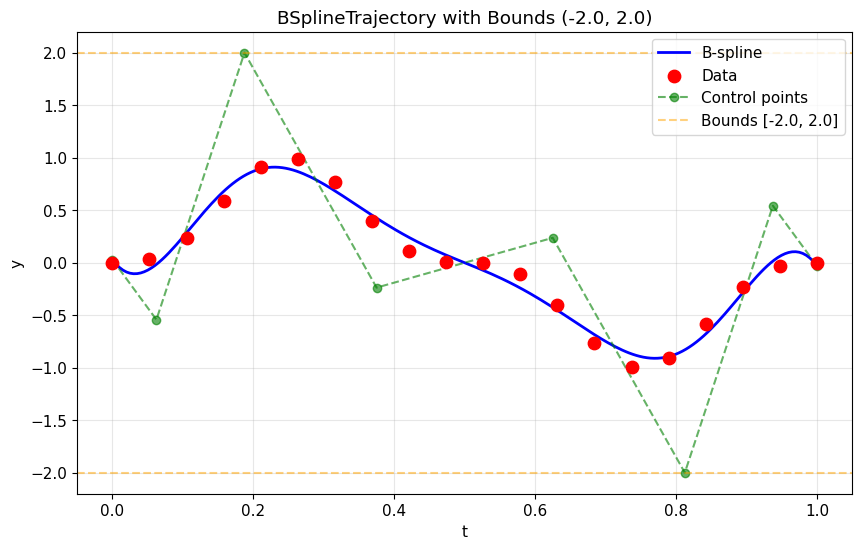

In [22]:
# Demo the class with bounds
BOUNDS = (-2.0, 2.0)

# Bounded fit
bspline_bounded = BSplineTrajectory(degree=4, n_control_points=8, bounds=BOUNDS)
residual_bounded = bspline_bounded.fit(t_data, y_data)

# Unbounded fit for comparison
bspline_unbounded = BSplineTrajectory(degree=4, n_control_points=8, bounds=None)
residual_unbounded = bspline_unbounded.fit(t_data, y_data)

print("BSplineTrajectory Demo (Bounded vs Unbounded):")
print(f"\nUnbounded:")
print(f"  Residual: {residual_unbounded:.6f}")
print(f"  Control point range: [{bspline_unbounded.get_tokens().min():.4f}, {bspline_unbounded.get_tokens().max():.4f}]")

print(f"\nBounded {BOUNDS}:")
print(f"  Residual: {residual_bounded:.6f}")
print(f"  Control point range: [{bspline_bounded.get_tokens().min():.4f}, {bspline_bounded.get_tokens().max():.4f}]")

# Plot bounded version
bspline_bounded.plot(t_data, y_data, f"BSplineTrajectory with Bounds {BOUNDS}")

Quantization Demo with Bounded B-spline:
Bounds: (-2.0, 2.0)

Control points: [ 0.02944888 -0.54227041  2.         -0.23716833  0.23716833 -2.
  0.54227041 -0.02944888]
Quantized (0-255): [129  93 255 112 143   0 162 126]


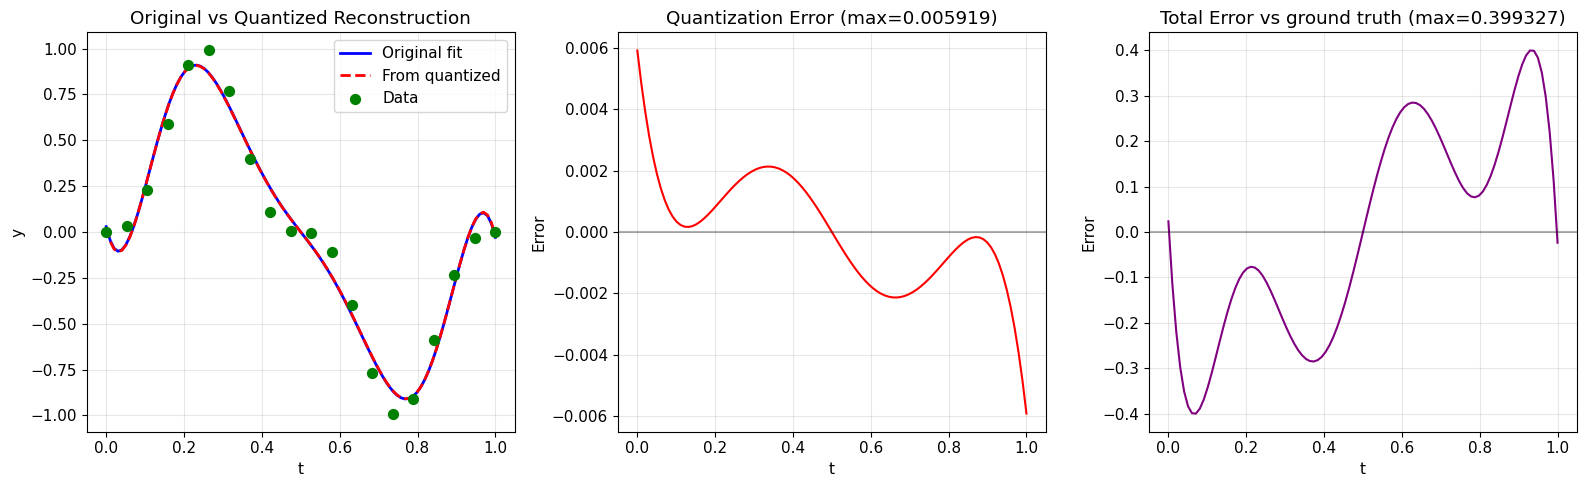


Error Summary:
  Max quantization error: 0.005919
  Max total error (vs true): 0.399327


In [23]:
# Demonstrate quantization with bounded B-spline
print("Quantization Demo with Bounded B-spline:")
print(f"Bounds: {BOUNDS}")

# Get tokens and quantize
tokens = bspline_bounded.get_tokens()
quantized = bspline_bounded.quantize(n_levels=256)

print(f"\nControl points: {tokens}")
print(f"Quantized (0-255): {quantized}")

# Reconstruct from quantized
bspline_recon = BSplineTrajectory(degree=4, n_control_points=8, bounds=BOUNDS)
bspline_recon.from_quantized(quantized, n_levels=256)

# Compare
t_test = np.linspace(0, 1, 100)
y_original = bspline_bounded.evaluate(t_test)
y_reconstructed = bspline_recon.evaluate(t_test)
y_true = np.sin(2 * np.pi * t_test)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Original vs Reconstructed
ax = axes[0]
ax.plot(t_test, y_original, 'b-', linewidth=2, label='Original fit')
ax.plot(t_test, y_reconstructed, 'r--', linewidth=2, label='From quantized')
ax.scatter(t_data, y_data, c='green', s=50, zorder=5, label='Data')
ax.set_xlabel('t')
ax.set_ylabel('y')
ax.set_title('Original vs Quantized Reconstruction')
ax.legend()
ax.grid(True, alpha=0.3)

# Quantization error
ax = axes[1]
ax.plot(t_test, y_original - y_reconstructed, 'r-', linewidth=1.5)
ax.axhline(0, color='k', linestyle='-', alpha=0.3)
ax.set_xlabel('t')
ax.set_ylabel('Error')
quant_err = np.max(np.abs(y_original - y_reconstructed))
ax.set_title(f'Quantization Error (max={quant_err:.6f})')
ax.grid(True, alpha=0.3)

# Total error vs ground truth
ax = axes[2]
ax.plot(t_test, y_reconstructed - y_true, 'purple', linewidth=1.5)
ax.axhline(0, color='k', linestyle='-', alpha=0.3)
ax.set_xlabel('t')
ax.set_ylabel('Error')
total_err = np.max(np.abs(y_reconstructed - y_true))
ax.set_title(f'Total Error vs ground truth (max={total_err:.6f})')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nError Summary:")
print(f"  Max quantization error: {quant_err:.6f}")
print(f"  Max total error (vs true): {total_err:.6f}")

## Summary

### Algorithm: Constrained Least Squares B-Spline Fitting

The regression finds optimal control points by solving:

$$\min_{\mathbf{c}} \|B\mathbf{c} - \mathbf{y}\|^2 \quad \text{subject to} \quad l \leq c_i \leq u$$

Where:
- $B$ is the B-spline basis matrix: $B_{ij} = B_{j,k}(t_i)$
- $\mathbf{c}$ are the control points
- $\mathbf{y}$ are the data values
- $l, u$ are the lower/upper bounds (e.g., -2.0, 2.0)

This is solved using `scipy.optimize.lsq_linear` with box constraints.

### Key Properties:
- **Clamped knot vector**: Ensures curve passes through first and last control points
- **Normalized domain**: $t \in [0, 1]$
- **Bounded control points**: Enforced during fitting for reliable quantization
- **Configurable**: Degree, number of control points, and bounds are parameters

### Tokenization Pipeline:
1. **Fit**: `bspline.fit(t, y)` with bounds constraint
2. **Quantize**: `bspline.quantize(n_levels=256)` → integer tokens
3. **Reconstruct**: `bspline.from_quantized(tokens)` → B-spline curve
4. **Evaluate**: `bspline.evaluate(t)` → trajectory values

### Trade-offs:
| Bounds | Fit Quality | Quantization |
|--------|-------------|--------------|
| Tight (±1.0) | May degrade for steep curves | Full resolution used |
| Moderate (±1.5) | Good for most trajectories | Good resolution |
| Wide (±2.0) | Minimal degradation | Some resolution wasted |
| Unbounded | Optimal fit | Risk of clipping |